# VWAP Pullback Continuation Final Validation Notebook


In [1]:
from pathlib import Path
import json
import sys
from IPython.display import Image, Markdown, display
import pandas as pd

root = Path.cwd().resolve()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent
if not (root / "pyproject.toml").exists():
    raise RuntimeError("Could not locate repository root.")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 120)


In [2]:
OUTPUT_DIR = Path(r"D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\vwap_pullback_validation_final_20260323")
print(OUTPUT_DIR)


D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\vwap_pullback_validation_final_20260323


## 1) Executive Summary


In [3]:
report = (OUTPUT_DIR / "summary" / "validation_report.md").read_text(encoding="utf-8")
display(Markdown(report))
verdict = json.loads((OUTPUT_DIR / "summary" / "final_verdict.json").read_text(encoding="utf-8"))
verdict


# VWAP Pullback Continuation Validation

## Executive Summary

- Final category: `candidat solide`
- Validation is based on the corrected next-open discrete execution semantics, not on the legacy discovery run.

## Nominal Corrected Run

```text
  scope     net_pnl  profit_factor  sharpe_ratio  max_drawdown  total_trades  expectancy_per_trade
overall 3948.664286       1.022287      0.162656  -7548.971429          4653              0.848628
     is 2707.917857       1.024768      0.184330  -4683.475000          3274              0.827098
    oos 1240.746429       1.018290      0.135068  -7548.971429          1379              0.899744
```

## Final Verdict Blocks

- Robustesse statistique: Le run de decouverte historique n'est pas defendable tel quel a cause d'une fuite temporelle discrete entree-close/same-bar; le rerun corrige ne montre plus qu'un edge tres faible.
- Robustesse execution: Le profil se degrade vite des qu'on stresse l'execution.
- Robustesse parametrique: La topologie locale reste etroite ou fragile.
- Robustesse temporelle: Le resultat reste tres dependant du split choisi.
- Viabilite prop firm: La strategie reste trop fragile pour un challenge prop en l'etat.

## Artifact Pointers

- Stress: not generated
- Local robustness: not generated
- Multi-split: not generated
- Concentration: not generated
- Challenge mode: not generated
- Cross instrument: not generated


{'statistical_robustness': "Le run de decouverte historique n'est pas defendable tel quel a cause d'une fuite temporelle discrete entree-close/same-bar; le rerun corrige ne montre plus qu'un edge tres faible.",
 'execution_robustness': "Le profil se degrade vite des qu'on stresse l'execution.",
 'parametric_robustness': 'La topologie locale reste etroite ou fragile.',
 'temporal_robustness': 'Le resultat reste tres dependant du split choisi.',
 'prop_firm_viability': "La strategie reste trop fragile pour un challenge prop en l'etat.",
 'concentration_verdict': None,
 'cross_instrument_verdict': None,
 'overall_category': 'candidat solide',
 'nominal_oos_net_pnl': 1240.7464285714595,
 'nominal_oos_profit_factor': 1.018289775506456,
 'nominal_oos_sharpe_ratio': 0.13506830204348877,
 'nominal_overall_net_pnl': 3948.664285714367}

## 2) Reference Config


In [4]:
display(Markdown((OUTPUT_DIR / "nominal" / "reference_spec.md").read_text(encoding="utf-8")))
reference_config = json.loads((OUTPUT_DIR / "nominal" / "reference_config.json").read_text(encoding="utf-8"))
reference_config


# Reference Spec

## Provenance

- Source run metadata: `D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\vwap_full_smoke_v2\summary\run_metadata.json`
- Source best variant: `vwap_pullback_continuation`
- Source run timestamp: `2026-03-23T00:25:52.630068`

## Audited Strategy Definition

- Strategy name: `vwap_pullback_continuation`
- Time windows: `full_rth`
- Slope lookback / threshold: `5` / `0.0`
- ATR period / buffer / stop buffer: `14` / `0.3` / `0.3`
- Pullback lookback: `8`
- Confirmation threshold: `0.0` ATR above/below `prev_high` / `prev_low`.
- Pullback definition: at least one counter-trend close inside the last pullback window, while the pullback extreme stays within the VWAP regime buffer.
- Confirmation definition: close-based continuation through `prev_high` / `prev_low`, executed on the next bar open.
- Stop logic: pullback extreme +/- `stop_buffer * ATR`.
- Exit logic: VWAP recross = `True`, plus structural stop, plus forced session close.
- Max trades per day: `3`
- Daily kill switches: `max_losses_per_day=None`, `daily_stop_threshold_usd=None`
- Sizing: `fixed_quantity`, fixed quantity `1`, risk per trade `None`
- Costs: commission `1.25` USD / side, slippage `1` tick(s) / side.
- Session assumptions: RTH `[09:30, 16:00)`, flat overnight, dataset `MNQ_c_0_1m_20260321_094501.parquet`.

## Audit Warnings

- `compression_length` is present in the config object but is not consumed by `generate_pullback_continuation_signals`; it is documented as inactive for this variant.
- `use_partial_exit`, `partial_exit_r_multiple`, and `keep_runner_until_close` are currently inactive in the VWAP discrete backtester and are excluded from robustness conclusions.
- The source discovery run selected `vwap_pullback_continuation` as best variant, but that legacy run used same-bar execution for close-based discrete entries. Validation reruns therefore use the corrected next-open semantics and should be treated as the only defendable evidence.


{'dataset_path': 'D:\\Business\\Trading\\VSCODE\\algo-trading-intraday-research\\data\\processed\\parquet\\MNQ_c_0_1m_20260321_094501.parquet',
 'reference_variant': {'name': 'vwap_pullback_continuation',
  'family': 'prop_variant',
  'mode': 'discrete',
  'execution_profile': 'repo_realistic',
  'initial_capital_usd': 50000.0,
  'quantity_mode': 'fixed_quantity',
  'fixed_quantity': 1,
  'time_windows': [],
  'slope_lookback': 5,
  'slope_threshold': 0.0,
  'atr_period': 14,
  'atr_buffer': 0.3,
  'stop_buffer': 0.3,
  'compression_length': 3,
  'pullback_lookback': 8,
  'confirmation_threshold': 0.0,
  'max_trades_per_day': 3,
  'max_losses_per_day': None,
  'daily_stop_threshold_usd': None,
  'consecutive_losses_threshold': None,
  'deleverage_after_losing_streak': 1.0,
  'risk_per_trade_pct': None,
  'exit_on_vwap_recross': True,
  'use_partial_exit': False,
  'partial_exit_r_multiple': 1.0,
  'keep_runner_until_close': True,
  'notes': 'Trend continuation after a contained pullbac

## 3) Nominal Metrics


In [5]:
metrics = pd.read_csv(OUTPUT_DIR / "nominal" / "metrics_summary_by_scope.csv")
display(metrics)
for name in ["monthly_pnl", "quarterly_pnl", "rolling_20d_metrics", "intraday_by_hour", "weekday_expectancy"]:
    path = OUTPUT_DIR / "nominal" / "tables" / f"{name}.csv"
    if path.exists():
        display(Markdown(f"### {name}"))
        display(pd.read_csv(path).head(20))


,scope,total_trades,n_trades,net_pnl,gross_pnl,gross_profit,gross_loss_abs,sharpe_ratio,sortino_ratio,profit_factor,hit_rate,expectancy_per_trade,expectancy_per_day,avg_win,avg_loss,avg_gain_loss_ratio,max_drawdown,return_over_max_drawdown,calmar_ratio,ulcer_index,annualized_vol,mean_trades_per_day,median_trades_per_day,max_trades_per_day,avg_time_in_position_min,avg_exposure_pct,long_trade_share,short_trade_share,worst_losing_trades_streak,worst_losing_days_streak,median_recovery_days,max_recovery_days,rolling_sharpe_20d_median,rolling_expectancy_20d_median,rolling_hit_rate_20d_median,top_1_day_contribution_pct,top_3_day_contribution_pct,top_5_day_contribution_pct,top_10_day_contribution_pct,bottom_1_day_contribution_pct,bottom_3_day_contribution_pct,bottom_5_day_contribution_pct,bottom_10_day_contribution_pct,pnl_excluding_top_1_day,pnl_excluding_top_3_days,pnl_excluding_top_5_days,pnl_excluding_best_month,top_day_contribution_ratio,reference_r_usd,worst_daily_loss_usd,days_below_neg_0p25r_freq,days_below_neg_0p5r_freq,days_below_neg_1r_freq,red_streak_ge_2_freq,red_streak_ge_3_freq,red_streak_ge_4_freq,red_streak_ge_5_freq,trade_loss_streak_ge_3_freq,trade_loss_streak_ge_4_freq,trade_loss_streak_ge_5_freq,trade_loss_streak_ge_6_freq,daily_loss_limit_breach_freq,trailing_drawdown_breach_freq,profit_to_drawdown_ratio
0,overall,4653,4653,3948.664286,15581.164286,183982.5,168401.335714,0.162656,0.224702,1.022287,0.241779,0.848628,2.260254,160.994222,-50.346643,3.197715,-7548.971429,0.523073,0.075452,5.575639,0.070035,2.663423,3.0,3,76.661079,0.325855,0.540082,0.459918,30,13,3.0,708.0,-0.260608,-2.264554,0.240741,0.454635,1.233759,1.768096,2.895141,-0.210507,-0.541585,-0.832304,-1.482920,2153.464286,-923.035714,-3032.953571,822.557143,2.895141,54.117857,-831.221429,0.579851,0.551231,0.476817,0.560000,0.328889,0.188889,0.115556,0.617788,0.457933,0.343750,0.253606,0.0,0.523183,0.523073
1,is,3274,3274,2707.917857,10892.917857,114003.5,103110.582143,0.184330,0.256833,1.024768,0.235186,0.827098,2.215972,145.505844,-43.750133,3.325838,-4683.475000,0.578186,0.119233,4.525359,0.060590,2.679214,3.0,3,75.359805,0.261994,0.532682,0.467318,30,13,4.0,708.0,-0.160345,-1.489643,0.236364,0.532143,1.209232,1.790305,3.138020,-0.193706,-0.543323,-0.860635,-1.595187,1266.917857,-566.582143,-2140.082143,757.807143,3.138020,47.698214,-524.539286,0.585106,0.561375,0.495090,0.556604,0.333333,0.188679,0.106918,0.640981,0.464098,0.367776,0.273205,0.0,0.427987,0.578186
2,oos,1379,1379,1240.746429,4688.246429,69979.0,65290.753571,0.135068,0.183970,1.018290,0.257433,0.899744,2.363327,194.588732,-66.508092,2.925790,-7548.971429,0.164360,0.078893,7.658508,0.088186,2.626667,3.0,3,79.750544,0.474405,0.557650,0.442350,21,11,3.0,384.0,-0.514499,-5.646875,0.258621,1.446871,3.676108,5.217519,8.554888,-0.669937,-1.723588,-2.648800,-4.652228,-554.453571,-3320.371429,-5232.871429,-1885.360714,8.554888,71.828571,-831.221429,0.567619,0.539048,0.470476,0.568182,0.318182,0.189394,0.136364,0.567050,0.444444,0.291188,0.210728,0.0,0.680000,0.164360


### monthly_pnl

,period,net_pnl_usd,days,avg_day_pnl_usd
0,2019-05,-126.728571,20,-6.336429
1,2019-06,-181.592857,19,-9.557519
2,2019-07,-67.714286,23,-2.944099
3,2019-08,15.685714,22,0.712987
4,2019-09,-506.235714,20,-25.311786
5,2019-10,-59.100000,23,-2.569565
6,2019-11,-375.753571,21,-17.893027
7,2019-12,-324.564286,20,-16.228214
8,2020-01,265.235714,22,12.056169
9,2020-02,-80.607143,20,-4.030357


### quarterly_pnl

,period,net_pnl_usd,days,avg_day_pnl_usd
0,2019Q2,-308.321429,39,-7.905678
1,2019Q3,-558.264286,65,-8.588681
2,2019Q4,-759.417857,64,-11.865904
3,2020Q1,-852.764286,63,-13.535941
4,2020Q2,2246.396429,63,35.657086
5,2020Q3,-2141.839286,65,-32.951374
6,2020Q4,-415.146429,64,-6.486663
7,2021Q1,-790.721429,62,-12.753571
8,2021Q2,15.207143,63,0.241383
9,2021Q3,-278.792857,65,-4.289121


...

,session_date,rolling_sharpe_20d,rolling_expectancy_20d,rolling_hit_rate_20d,rolling_trade_count_20d
0,2019-05-06,NaN,NaN,NaN,NaN
1,2019-05-07,NaN,NaN,NaN,NaN
2,2019-05-08,NaN,NaN,NaN,NaN
3,2019-05-09,NaN,NaN,NaN,NaN
4,2019-05-10,NaN,NaN,NaN,NaN
5,2019-05-13,NaN,NaN,NaN,NaN
6,2019-05-14,NaN,NaN,NaN,NaN
7,2019-05-15,NaN,NaN,NaN,NaN
8,2019-05-16,NaN,NaN,NaN,NaN
9,2019-05-17,NaN,NaN,NaN,NaN


### intraday_by_hour

,hour,bars,net_bar_pnl_usd,avg_bar_pnl_usd,trades,net_pnl_usd,expectancy_per_trade,win_rate
0,09:00,52365,-8686.203571,-0.165878,889,4714.539286,5.303194,0.287964
1,10:00,104753,-57717.214286,-0.550984,1959,-2878.467857,-1.469356,0.224604
2,11:00,104652,-24750.967857,-0.236507,900,2732.500000,3.036111,0.210000
3,12:00,104577,-14401.942857,-0.137716,388,-987.489286,-2.545075,0.198454
4,13:00,101107,-1327.021429,-0.013125,216,913.753571,4.230341,0.254630
5,14:00,100919,-1452.853571,-0.014396,119,-124.196429,-1.043667,0.327731
6,15:00,100980,157911.367857,1.563789,182,-421.975000,-2.318544,0.379121


### weekday_expectancy

,weekday,days,net_pnl_usd,expectancy_per_day,green_day_pct
0,Monday,355,408.221429,1.149920,0.422535
1,Tuesday,359,2549.139286,7.100667,0.403900
2,Wednesday,355,-3669.810714,-10.337495,0.369014
3,Thursday,356,4675.785714,13.134230,0.387640
4,Friday,322,-14.671429,-0.045563,0.391304


## 4) Stress Tests


In [6]:
path = OUTPUT_DIR / "stress" / "stress_test_summary.csv"
if path.exists():
    display(pd.read_csv(path))


,scenario,notes,overall_net_pnl,overall_profit_factor,overall_sharpe_ratio,overall_max_drawdown,oos_net_pnl,oos_profit_factor,oos_sharpe_ratio,oos_max_drawdown,delta_oos_net_pnl_vs_nominal,delta_oos_profit_factor_vs_nominal,delta_oos_sharpe_vs_nominal
0,combined_x2_plus25,Slippage x2 + commission +25%.,-3612.460714,0.980251,-0.148398,-9090.728571,-1000.128571,0.985611,-0.108638,-9090.728571,-2240.875,-0.032678,-0.243707
1,combined_x3_plus50,Slippage x3 + commission +50%.,-11173.585714,0.940786,-0.457739,-11569.767857,-3241.003571,0.954477,-0.351286,-10741.728571,-4481.750,-0.063813,-0.486354
2,commission_plus_25pct,Commission +25%.,1040.539286,1.005801,0.042817,-8074.728571,378.871429,1.005533,0.041210,-8074.728571,-861.875,-0.012757,-0.093859
3,commission_plus_50pct,Commission +50%.,-1867.585714,0.989715,-0.076768,-8709.728571,-483.003571,0.993012,-0.052492,-8709.728571,-1723.750,-0.025278,-0.187561
4,entry_penalty_1tick,Extra one-tick entry penalty on every trade.,1622.164286,1.009066,0.066765,-7947.728571,551.246429,1.008065,0.059969,-7947.728571,-689.500,-0.010225,-0.075099
5,nominal,Base run.,3948.664286,1.022287,0.162656,-7548.971429,1240.746429,1.018290,0.135068,-7548.971429,0.000,0.000000,0.000000
6,open_penalty_early15m,Extra one-tick entry penalty during the first ...,3890.164286,1.021952,0.160249,-7557.471429,1225.746429,1.018066,0.133437,-7557.471429,-15.000,-0.000224,-0.001631
7,slippage_x2,Slippage doubled.,-704.335714,0.996102,-0.028964,-8455.728571,-138.253571,0.997992,-0.015030,-8455.728571,-1379.000,-0.020297,-0.150099
8,slippage_x3,Slippage tripled.,-5357.335714,0.970923,-0.219936,-9471.728571,-1517.253571,0.978293,-0.164728,-9471.728571,-2758.000,-0.039997,-0.299796


## 5) Parametric Robustness


,verdict,stable_neighbor_share,reference_sharpe_rank_pct,comment,pair_name
0,stable localement,0.666667,0.333333,La case de reference reste entouree d'un plate...,slope_threshold_x_atr_buffer
1,instable / pic etroit,0.222222,0.111111,La reference n'est soutenue que par peu de voi...,pullback_length_x_confirmation_threshold
2,stable localement,1.000000,1.000000,La case de reference reste entouree d'un plate...,open_window_end_x_max_trades
3,moderetement stable,0.500000,0.111111,"Le voisinage n'est pas vide, mais la robustess...",daily_stop_threshold_x_consecutive_losses_proxy


### daily_stop_threshold_x_consecutive_losses_proxy

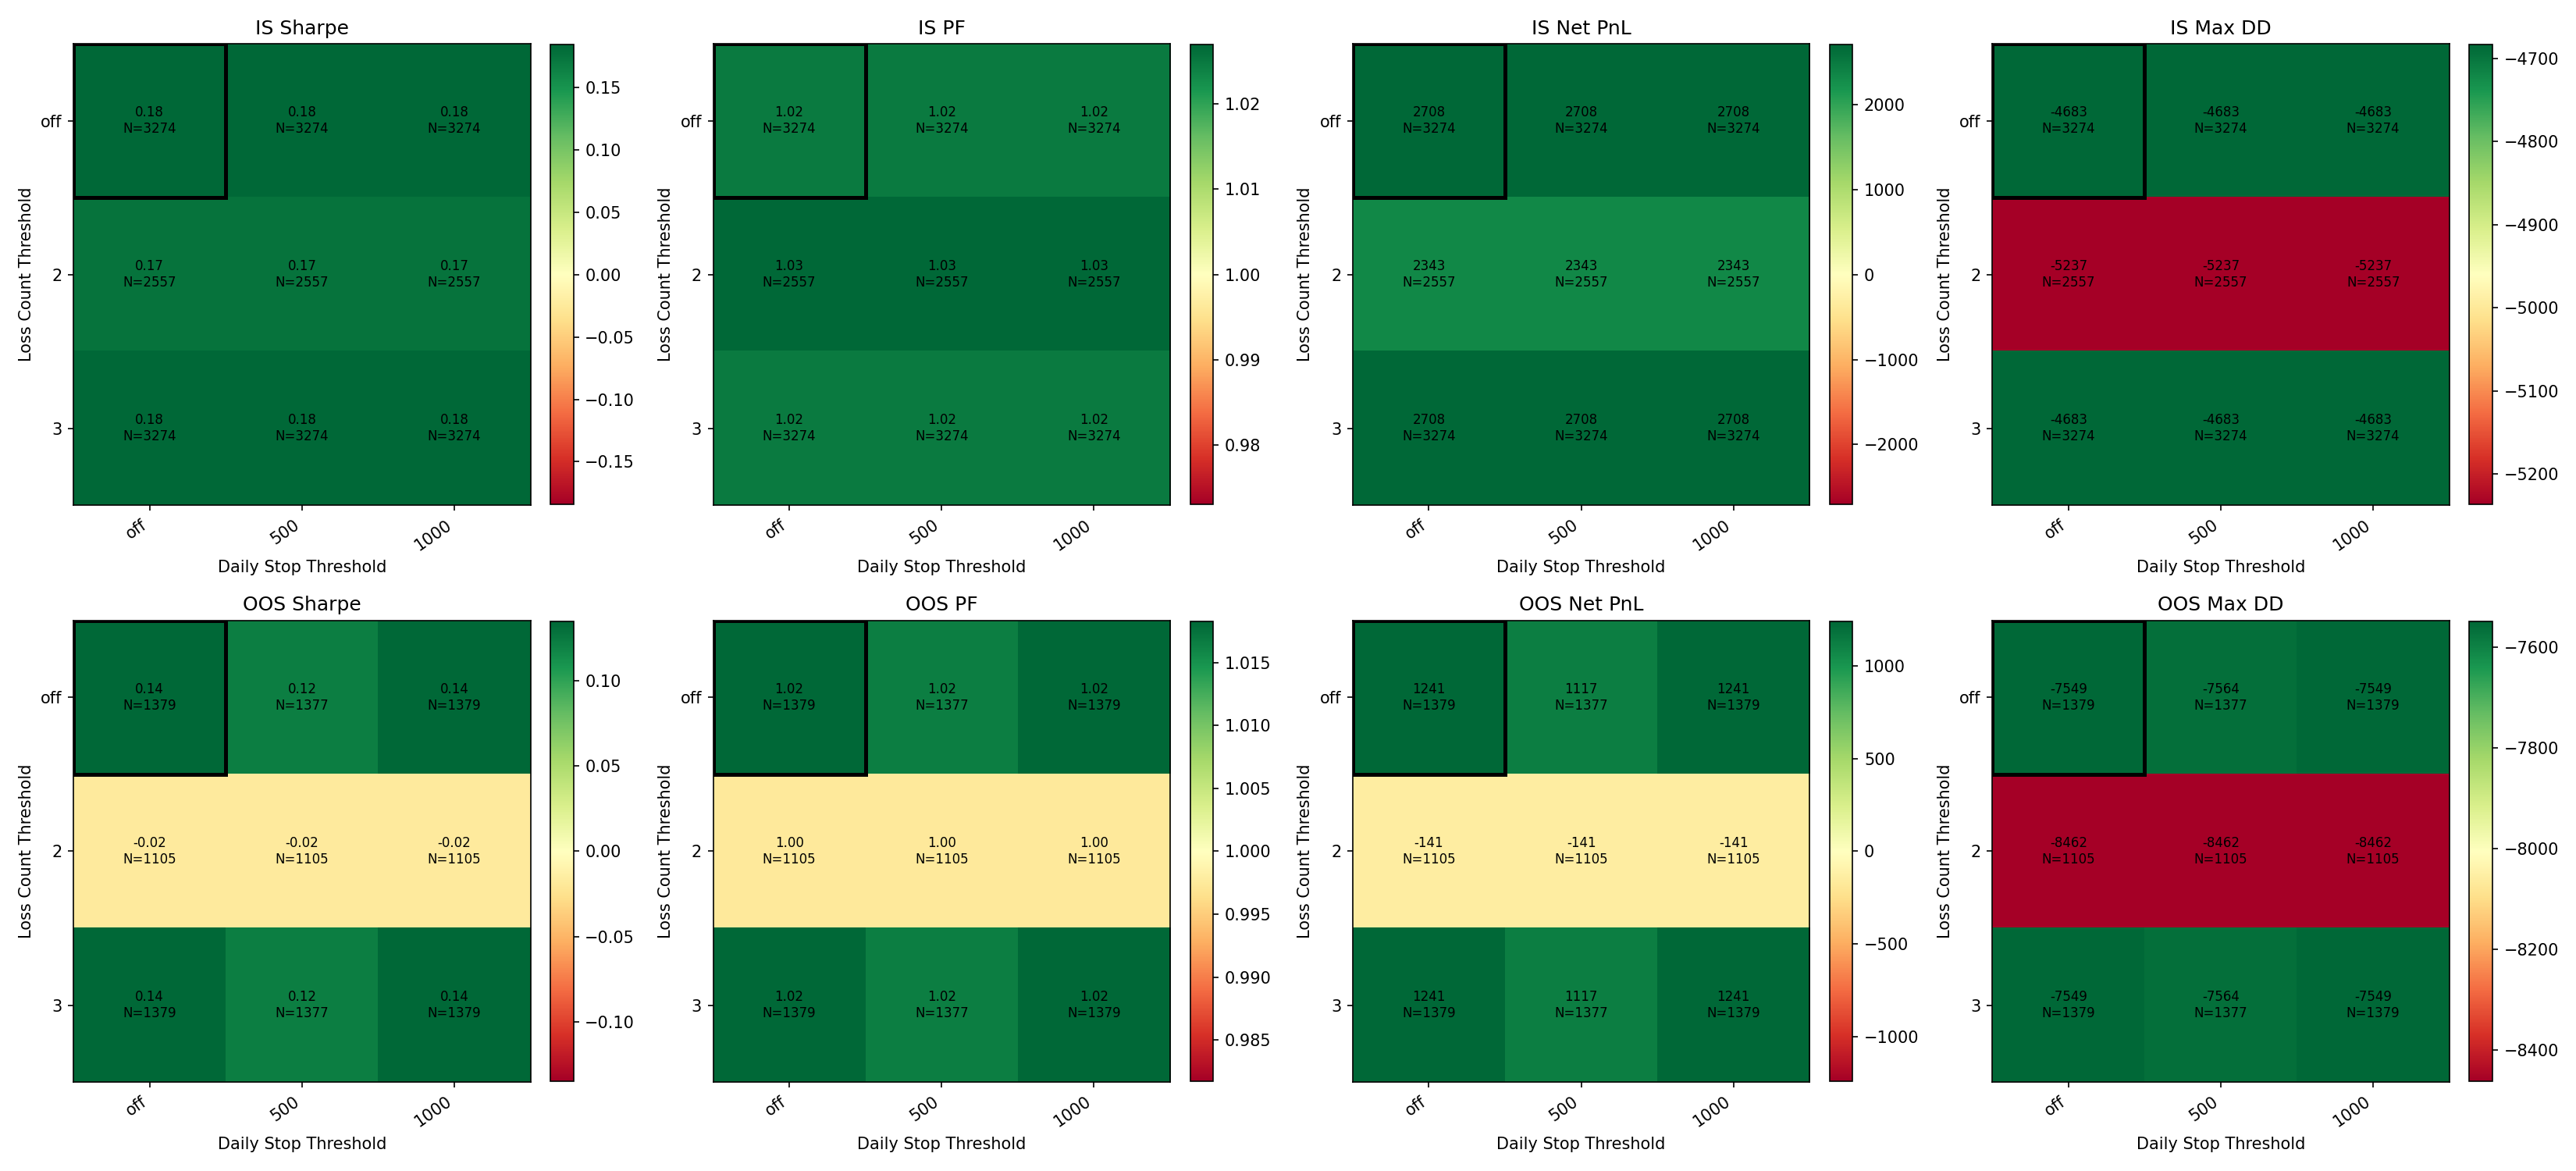

### open_window_end_x_max_trades

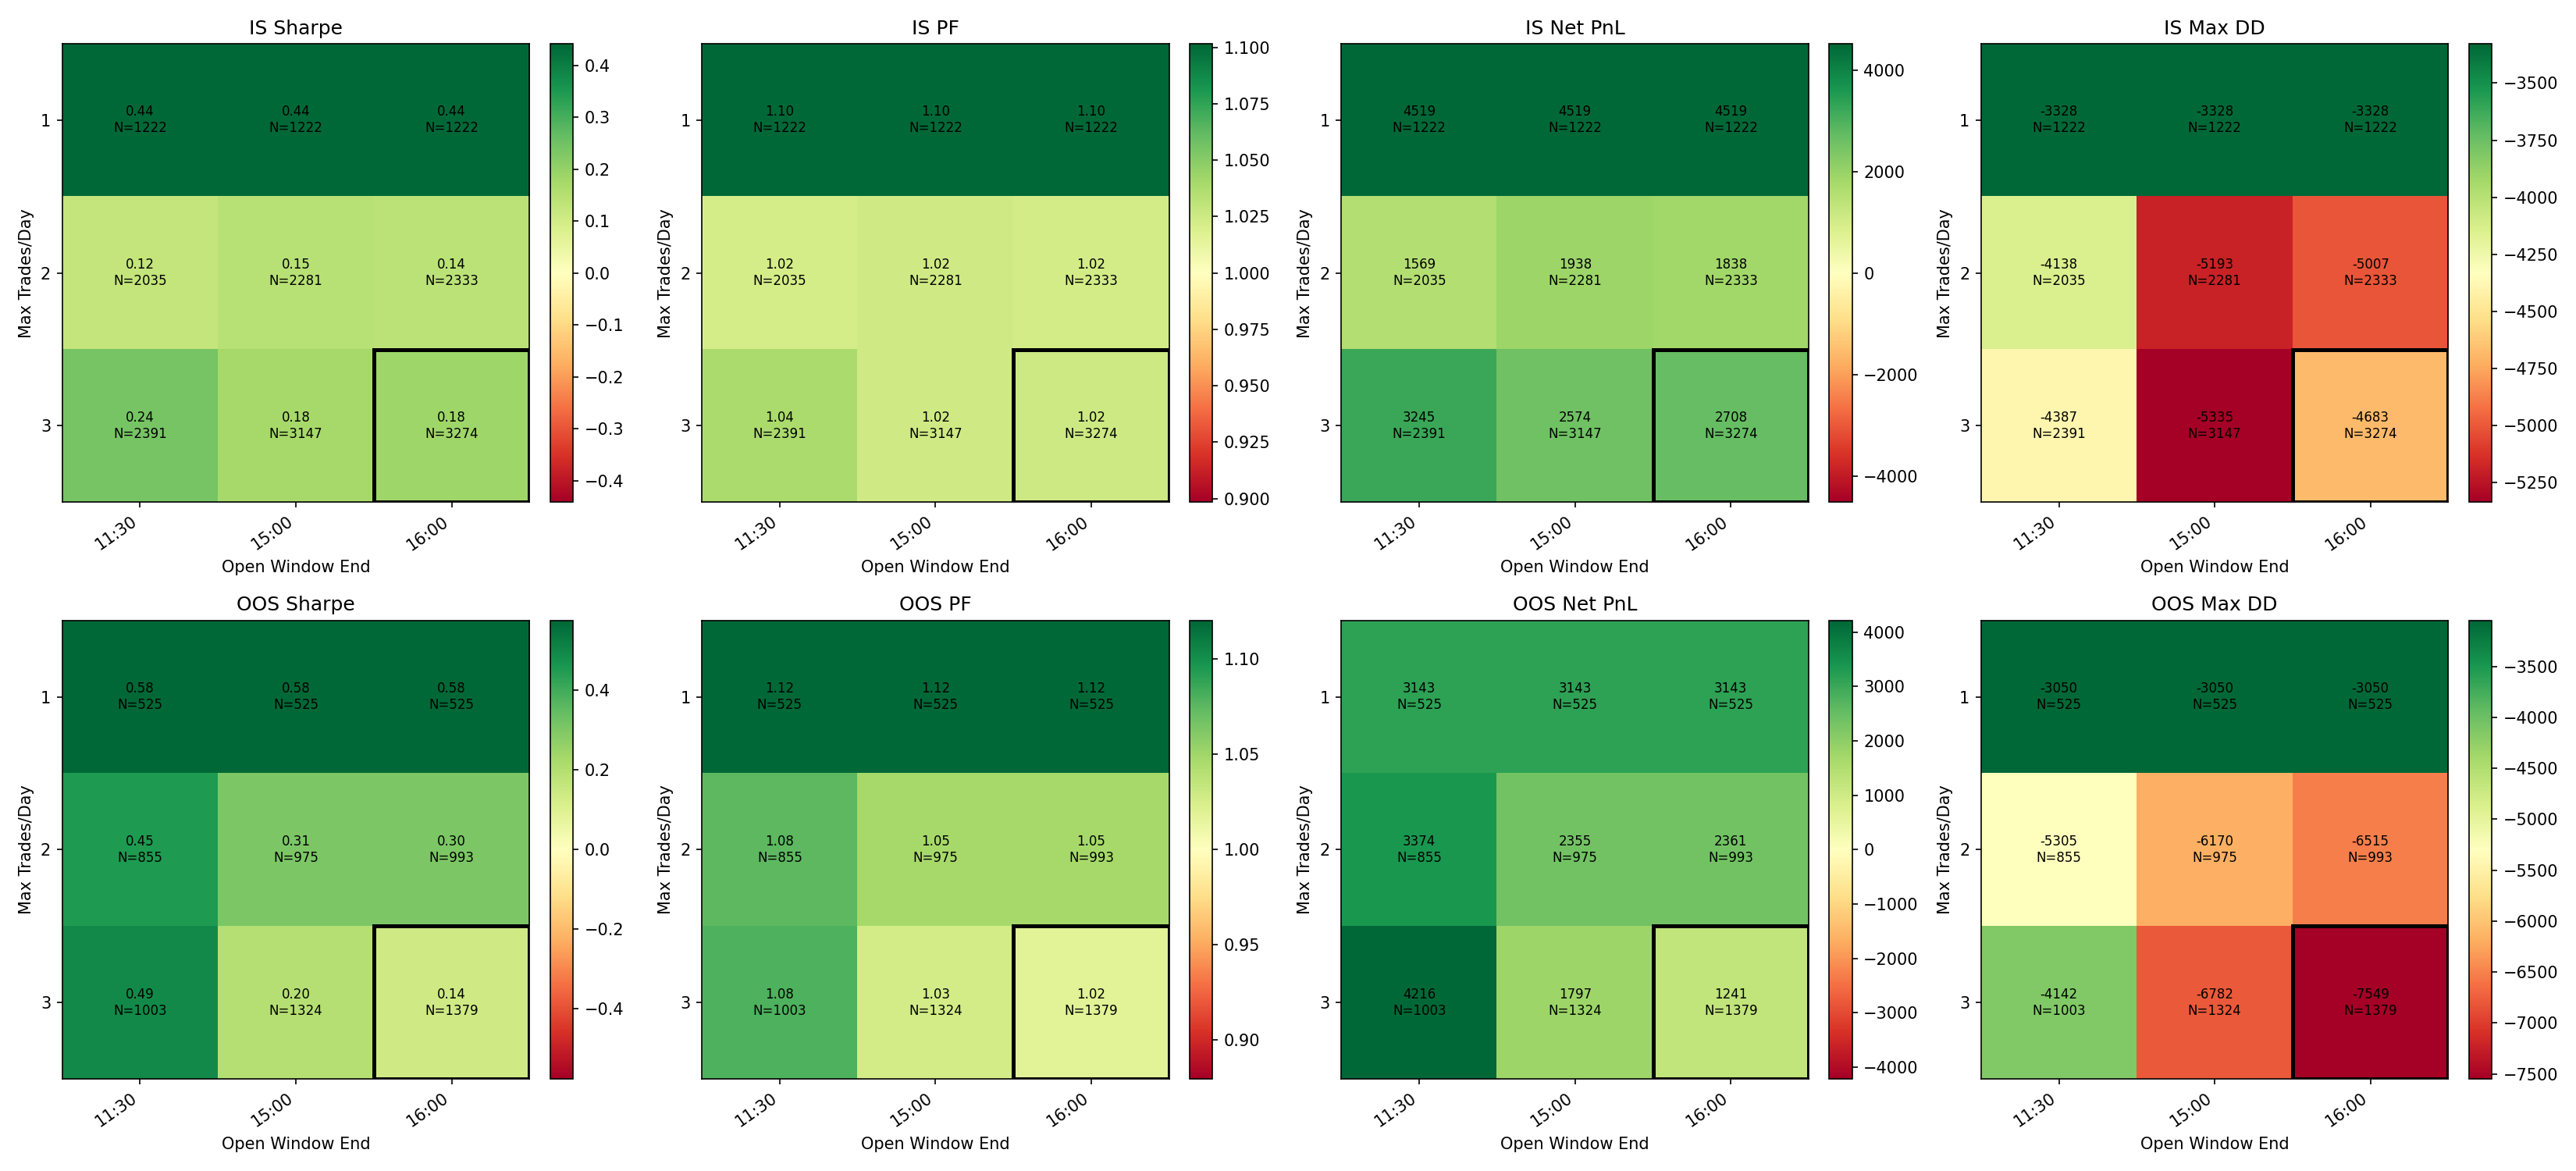

### pullback_length_x_confirmation_threshold

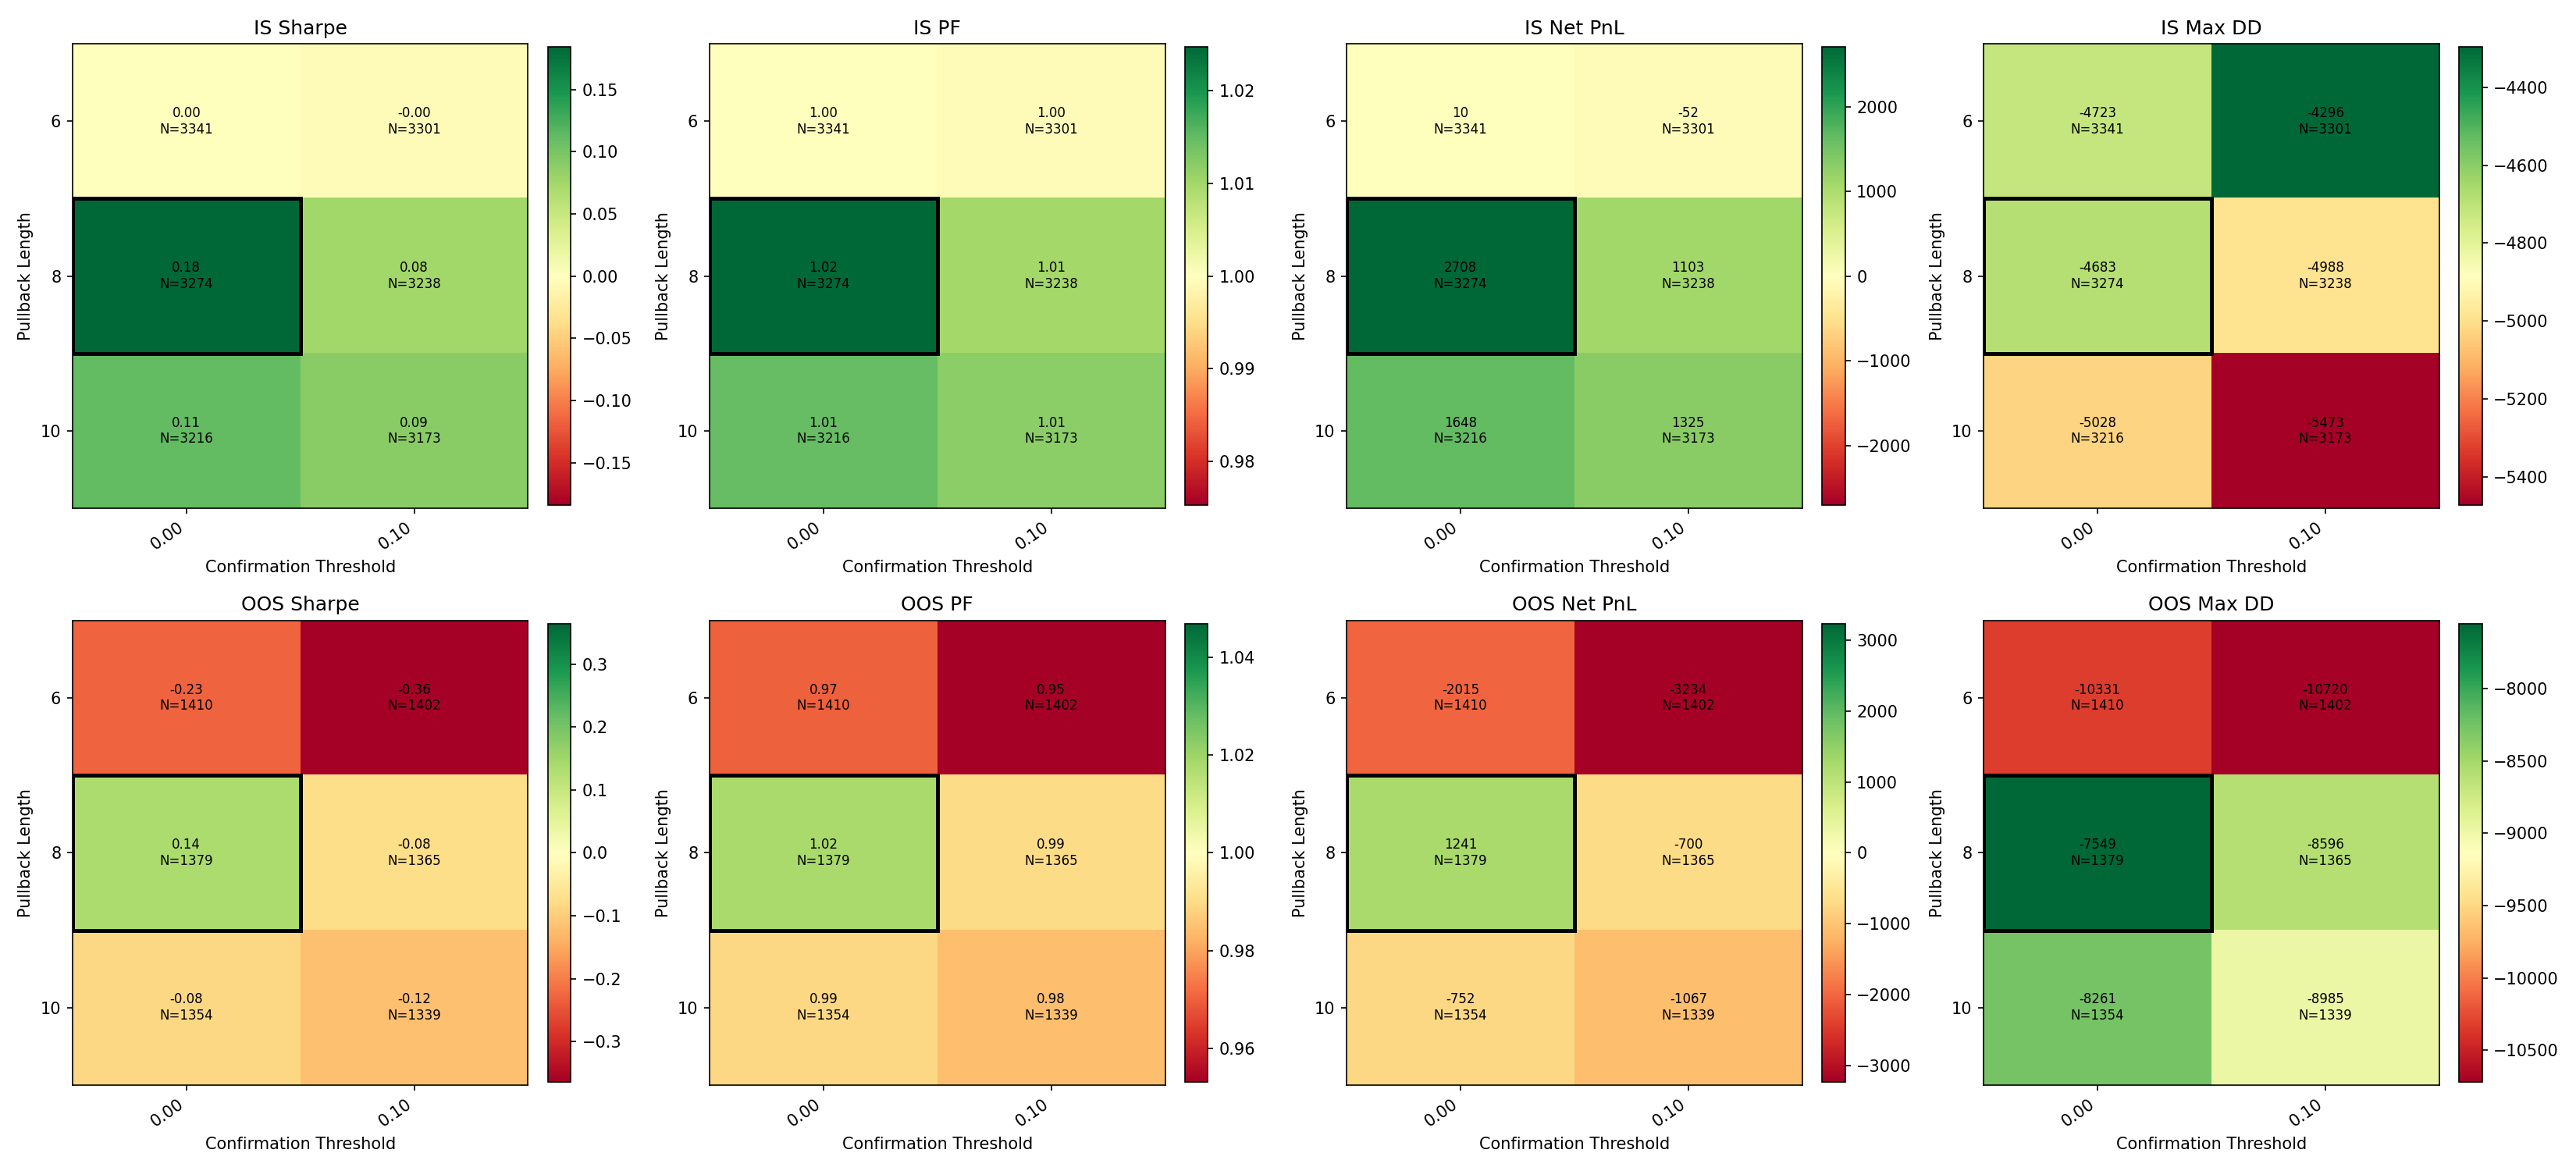

### slope_threshold_x_atr_buffer

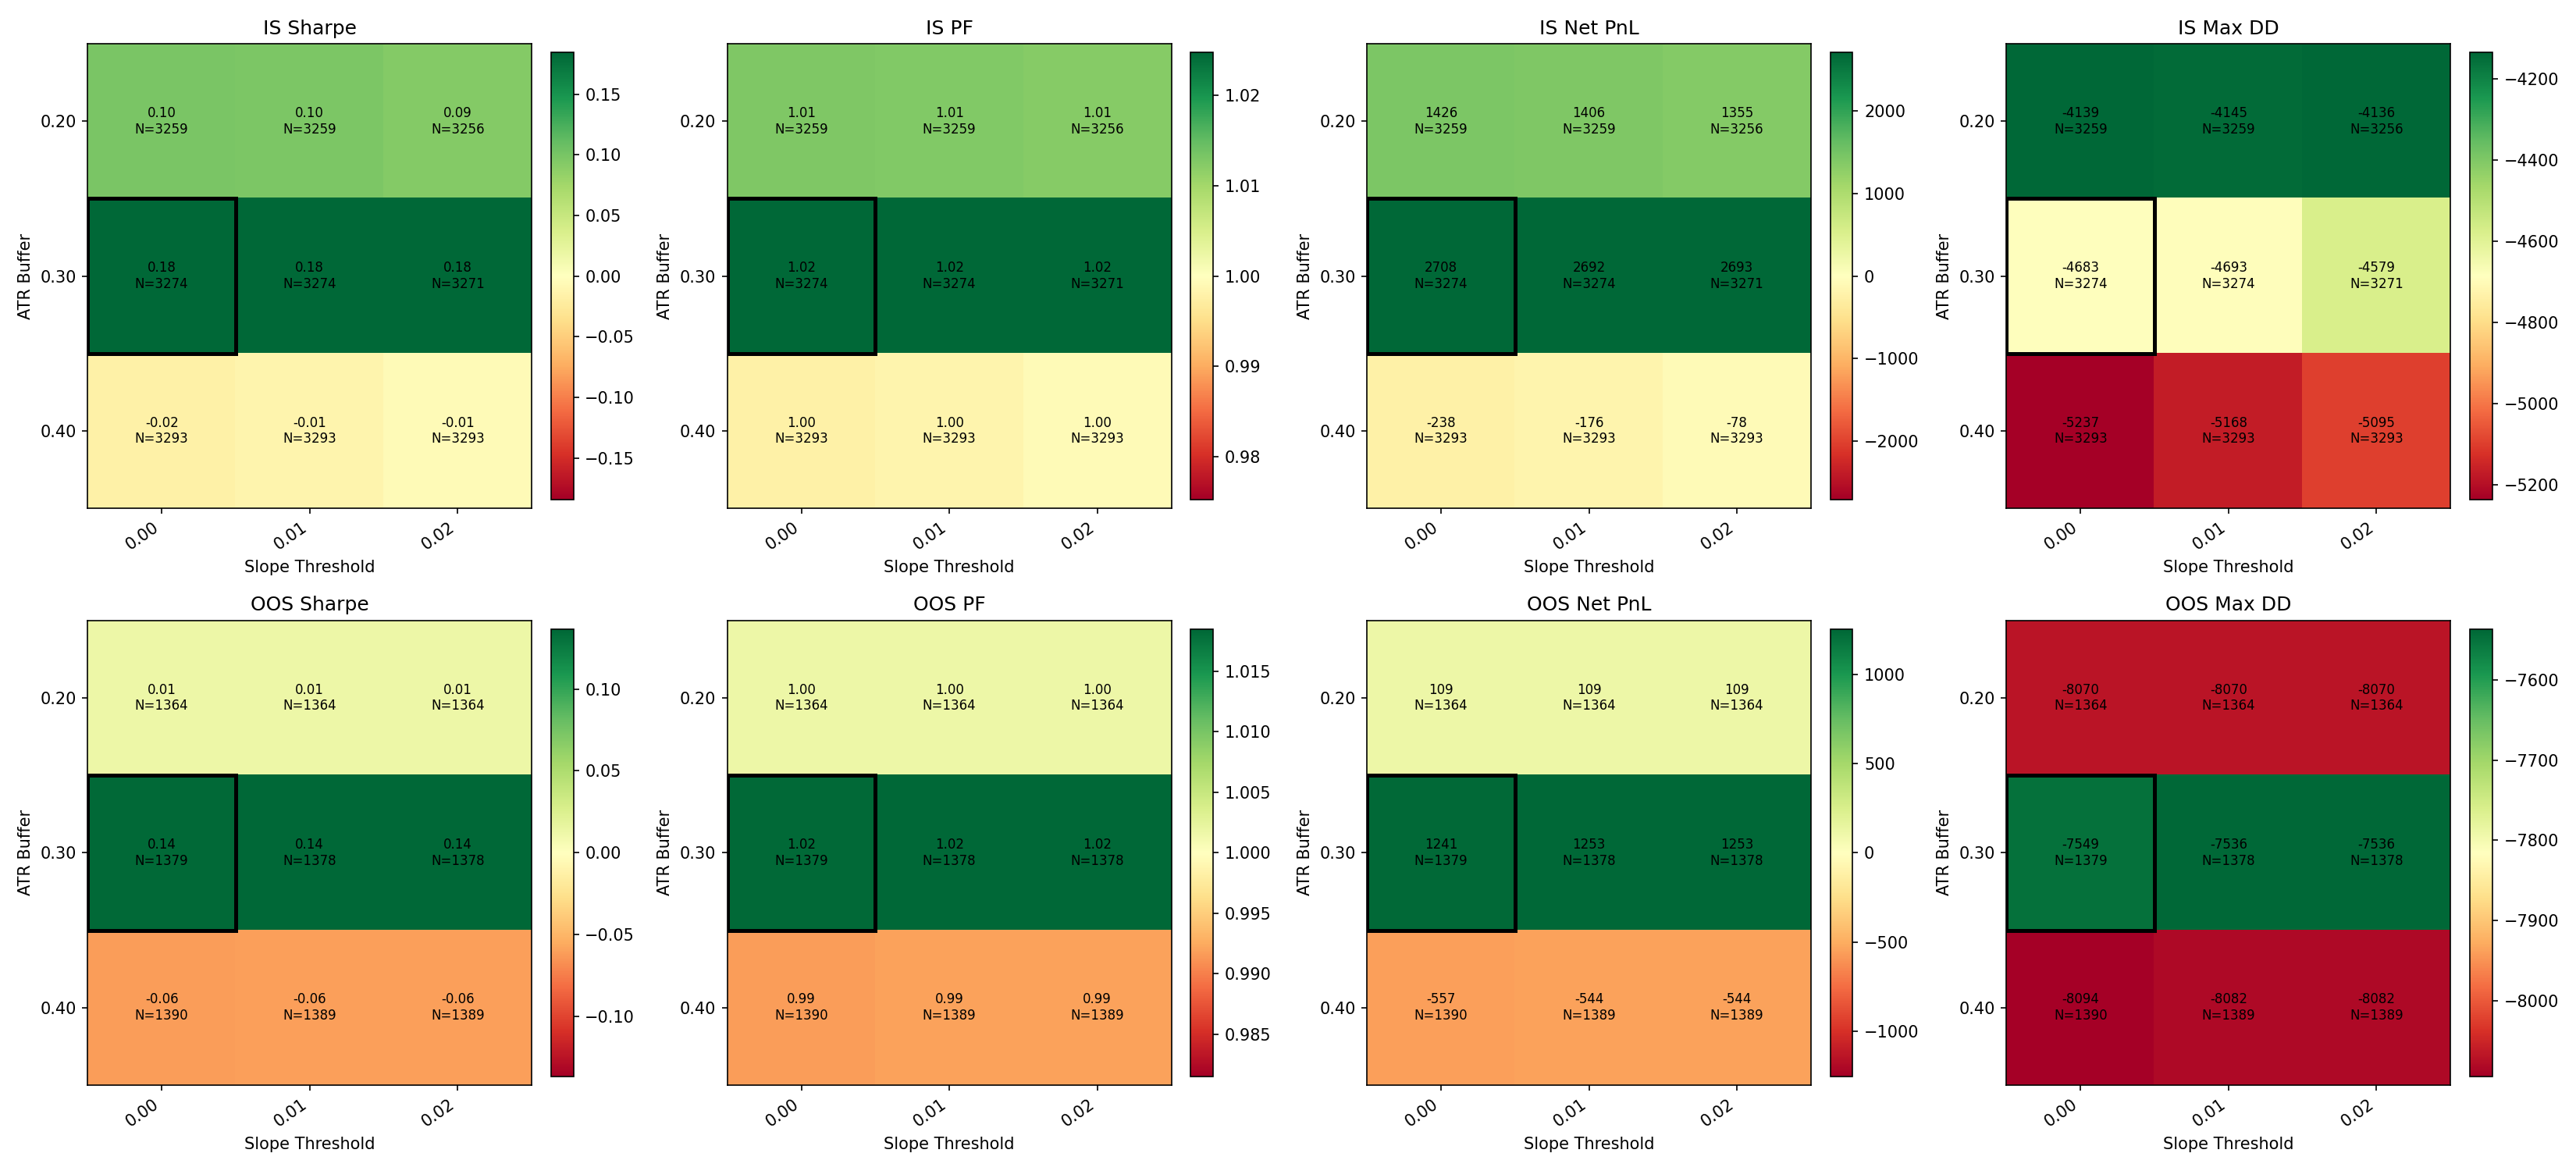

In [7]:
path = OUTPUT_DIR / "local_robustness" / "heatmap_readouts.csv"
if path.exists():
    display(pd.read_csv(path))
for png in sorted((OUTPUT_DIR / "local_robustness" / "heatmaps").glob("*.png")):
    display(Markdown(f"### {png.stem}"))
    display(Image(filename=str(png)))


## 6) Multi-Split


In [8]:
path = OUTPUT_DIR / "multi_split" / "split_summary.csv"
if path.exists():
    display(pd.read_csv(path))


,split_name,is_fraction,oos_start_date,is_sharpe_ratio,is_profit_factor,is_net_pnl,is_max_drawdown,is_total_trades,oos_sharpe_ratio,oos_profit_factor,oos_net_pnl,oos_max_drawdown,oos_total_trades
0,is_60_oos_40,0.60,2023-06-20,0.403719,1.055188,5177.492857,-4683.475,2801,-0.109451,0.985258,-1228.828571,-7548.971429,1852
1,is_65_oos_35,0.65,2023-10-20,0.299799,1.040781,4158.682143,-4683.475,3037,-0.020726,0.997207,-210.017857,-7548.971429,1616
2,is_70_oos_30,0.70,2024-02-23,0.184330,1.024768,2707.917857,-4683.475,3274,0.135068,1.018290,1240.746429,-7548.971429,1379
3,is_75_oos_25,0.75,2024-07-01,0.312066,1.042437,4968.296429,-4683.475,3510,-0.128623,0.983033,-1019.632143,-7548.971429,1143


## 7) Concentration


,scope,top_1_day_contribution_pct,top_3_day_contribution_pct,top_5_day_contribution_pct,top_10_day_contribution_pct,pnl_excluding_top_1_day,pnl_excluding_top_3_days,pnl_excluding_top_5_days,pnl_excluding_best_month,verdict
0,overall,0.454635,1.233759,1.768096,2.895141,2153.464286,-923.035714,-3032.953571,822.557143,forte dependance aux meilleurs jours


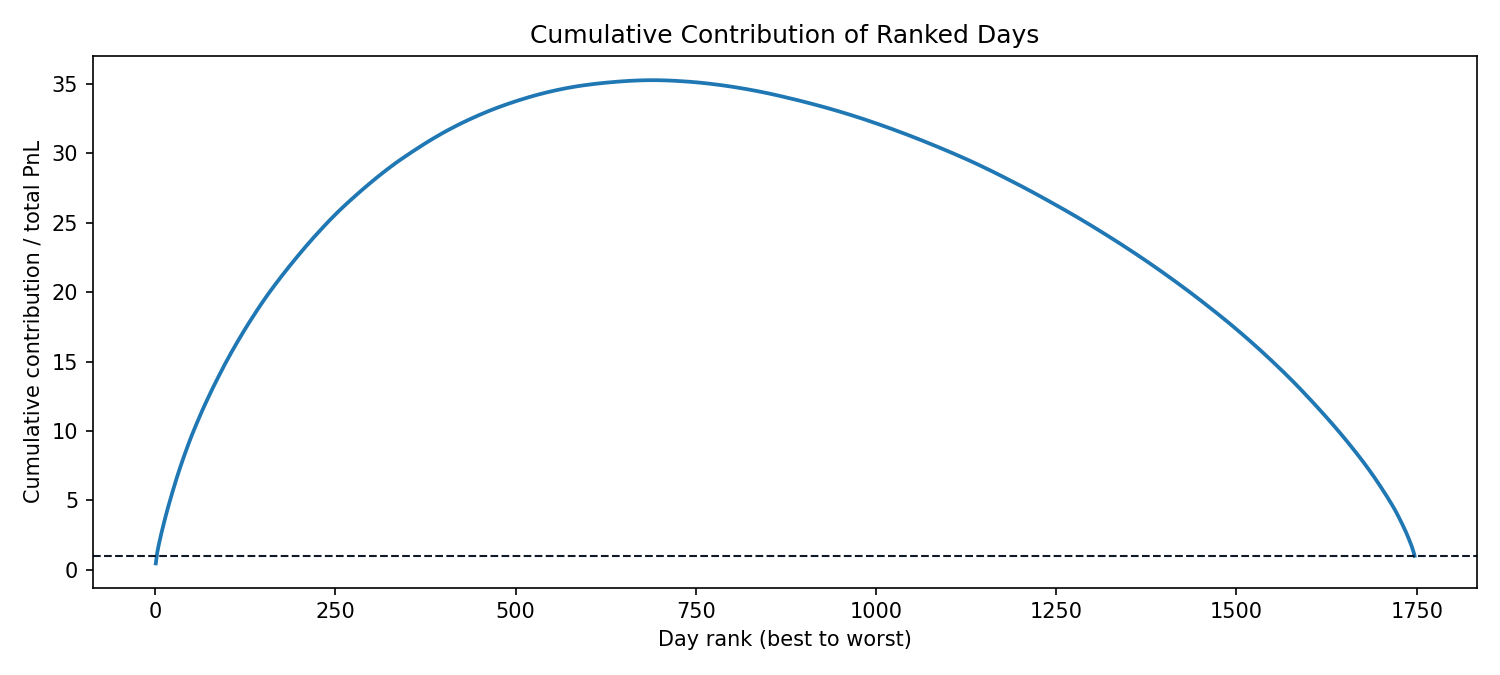

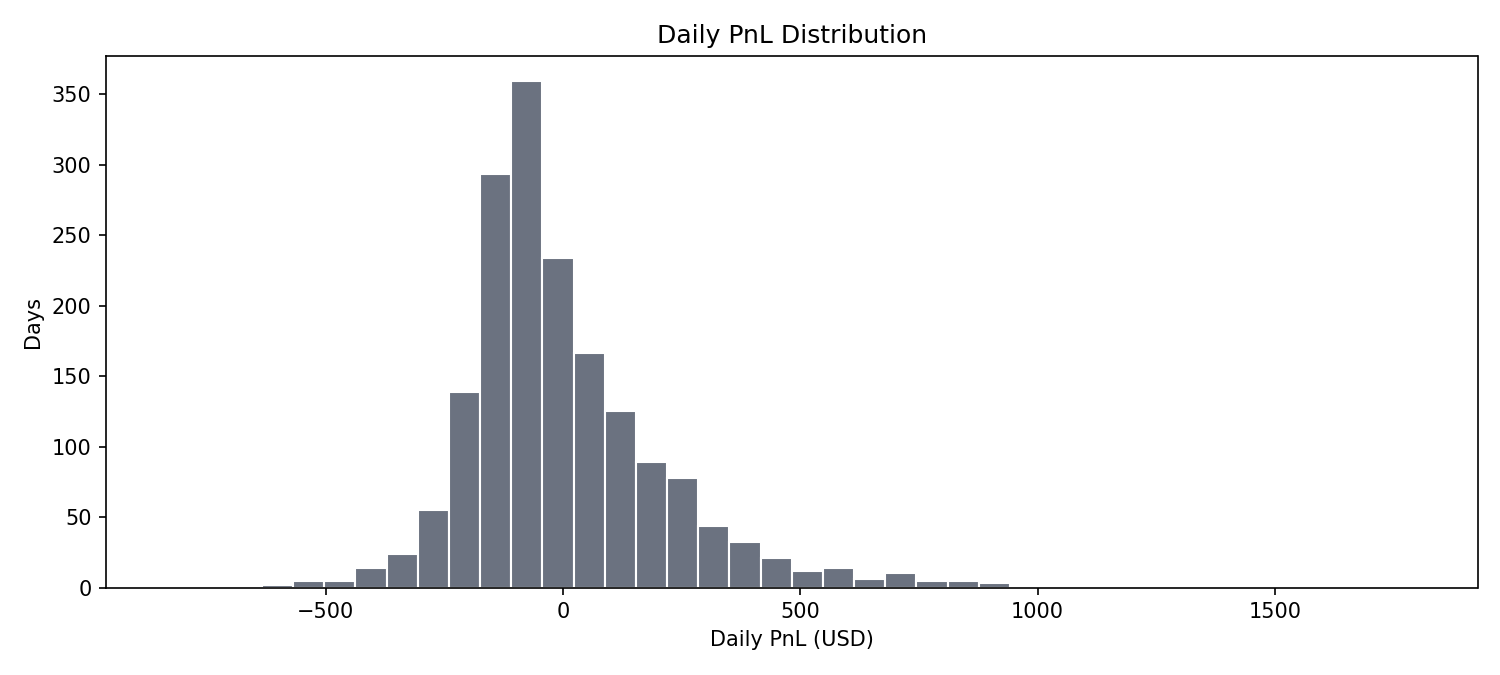

In [9]:
path = OUTPUT_DIR / "concentration" / "concentration_summary.csv"
if path.exists():
    display(pd.read_csv(path))
for png in sorted((OUTPUT_DIR / "concentration" / "charts").glob("*.png")):
    display(Image(filename=str(png)))


## 8) Challenge Mode


In [10]:
path = OUTPUT_DIR / "challenge_mode" / "challenge_mode_summary.csv"
if path.exists():
    display(pd.read_csv(path))


,scenario,label,success_rate_empirical,median_days_to_target,bust_rate_empirical,max_drawdown_usd_worst_path,average_daily_loss_limit_breaches,target_usd,horizon_days,daily_loss_limit_usd,trailing_drawdown_limit_usd,risk_per_trade_pct,max_contracts,historical_path_success,historical_days_to_target,historical_path_busted,historical_path_final_pnl_usd
0,scenario_c_aggressive_controlled,C_aggressive_controlled,0.121905,16.5,0.158095,-2509.132143,0.0,3000.0,30,1250.0,2250.0,0.3,6,True,41.0,False,3116.785714
1,scenario_b_standard,B_standard,0.081905,31.0,0.140952,-2168.185714,0.0,3000.0,45,1000.0,2000.0,0.2,4,True,97.0,False,3939.446429
2,scenario_a_conservative,A_conservative,0.000000,NaN,0.000000,-1166.717857,0.0,3000.0,60,750.0,1500.0,0.1,2,False,NaN,True,-369.914286


## 9) Cross Instrument


In [11]:
path = OUTPUT_DIR / "cross_instrument" / "cross_instrument_summary.csv"
if path.exists():
    display(pd.read_csv(path))


,symbol,dataset_path,overall_net_pnl,overall_profit_factor,overall_sharpe_ratio,overall_max_drawdown,oos_net_pnl,oos_profit_factor,oos_sharpe_ratio,oos_max_drawdown,oos_net_pnl_stress_x2_plus25,oos_profit_factor_stress_x2_plus25
0,MNQ,D:\Business\Trading\VSCODE\algo-trading-intrad...,3948.664286,1.022287,0.162656,-7548.971429,1240.746429,1.018290,0.135068,-7548.971429,-1000.128571,0.985611
1,NQ,D:\Business\Trading\VSCODE\algo-trading-intrad...,123936.571429,1.056368,0.329753,-57511.392857,119713.607143,1.090526,0.649887,-57511.392857,85851.732143,1.063710
2,MES,D:\Business\Trading\VSCODE\algo-trading-intrad...,-16891.437500,0.847746,-1.228637,-17216.598214,-3175.017857,0.917497,-0.643892,-5326.830357,-7478.142857,0.820979


## 10) Representative Days


,label,session_date,chart_path,comment
0,excellent,2025-11-20,data\exports\vwap_pullback_validation_final_20...,"3 trades, net 1795.2 USD, dominant direction l..."
1,excellent,2025-04-08,data\exports\vwap_pullback_validation_final_20...,"2 trades, net 1635.5 USD, dominant direction l..."
2,bad,2025-04-07,data\exports\vwap_pullback_validation_final_20...,"3 trades, net -831.2 USD, dominant direction l..."
3,bad,2025-04-09,data\exports\vwap_pullback_validation_final_20...,"3 trades, net -676.5 USD, dominant direction s..."
4,choppy,2019-12-24,data\exports\vwap_pullback_validation_final_20...,"3 trades, net 0.4 USD, dominant direction long..."
5,choppy,2025-07-10,data\exports\vwap_pullback_validation_final_20...,"3 trades, net 0.8 USD, dominant direction shor..."
6,clean_average,2021-10-22,data\exports\vwap_pullback_validation_final_20...,"3 trades, net -48.5 USD, dominant direction sh..."
7,clean_average,2024-12-02,data\exports\vwap_pullback_validation_final_20...,"3 trades, net -48.5 USD, dominant direction lo..."


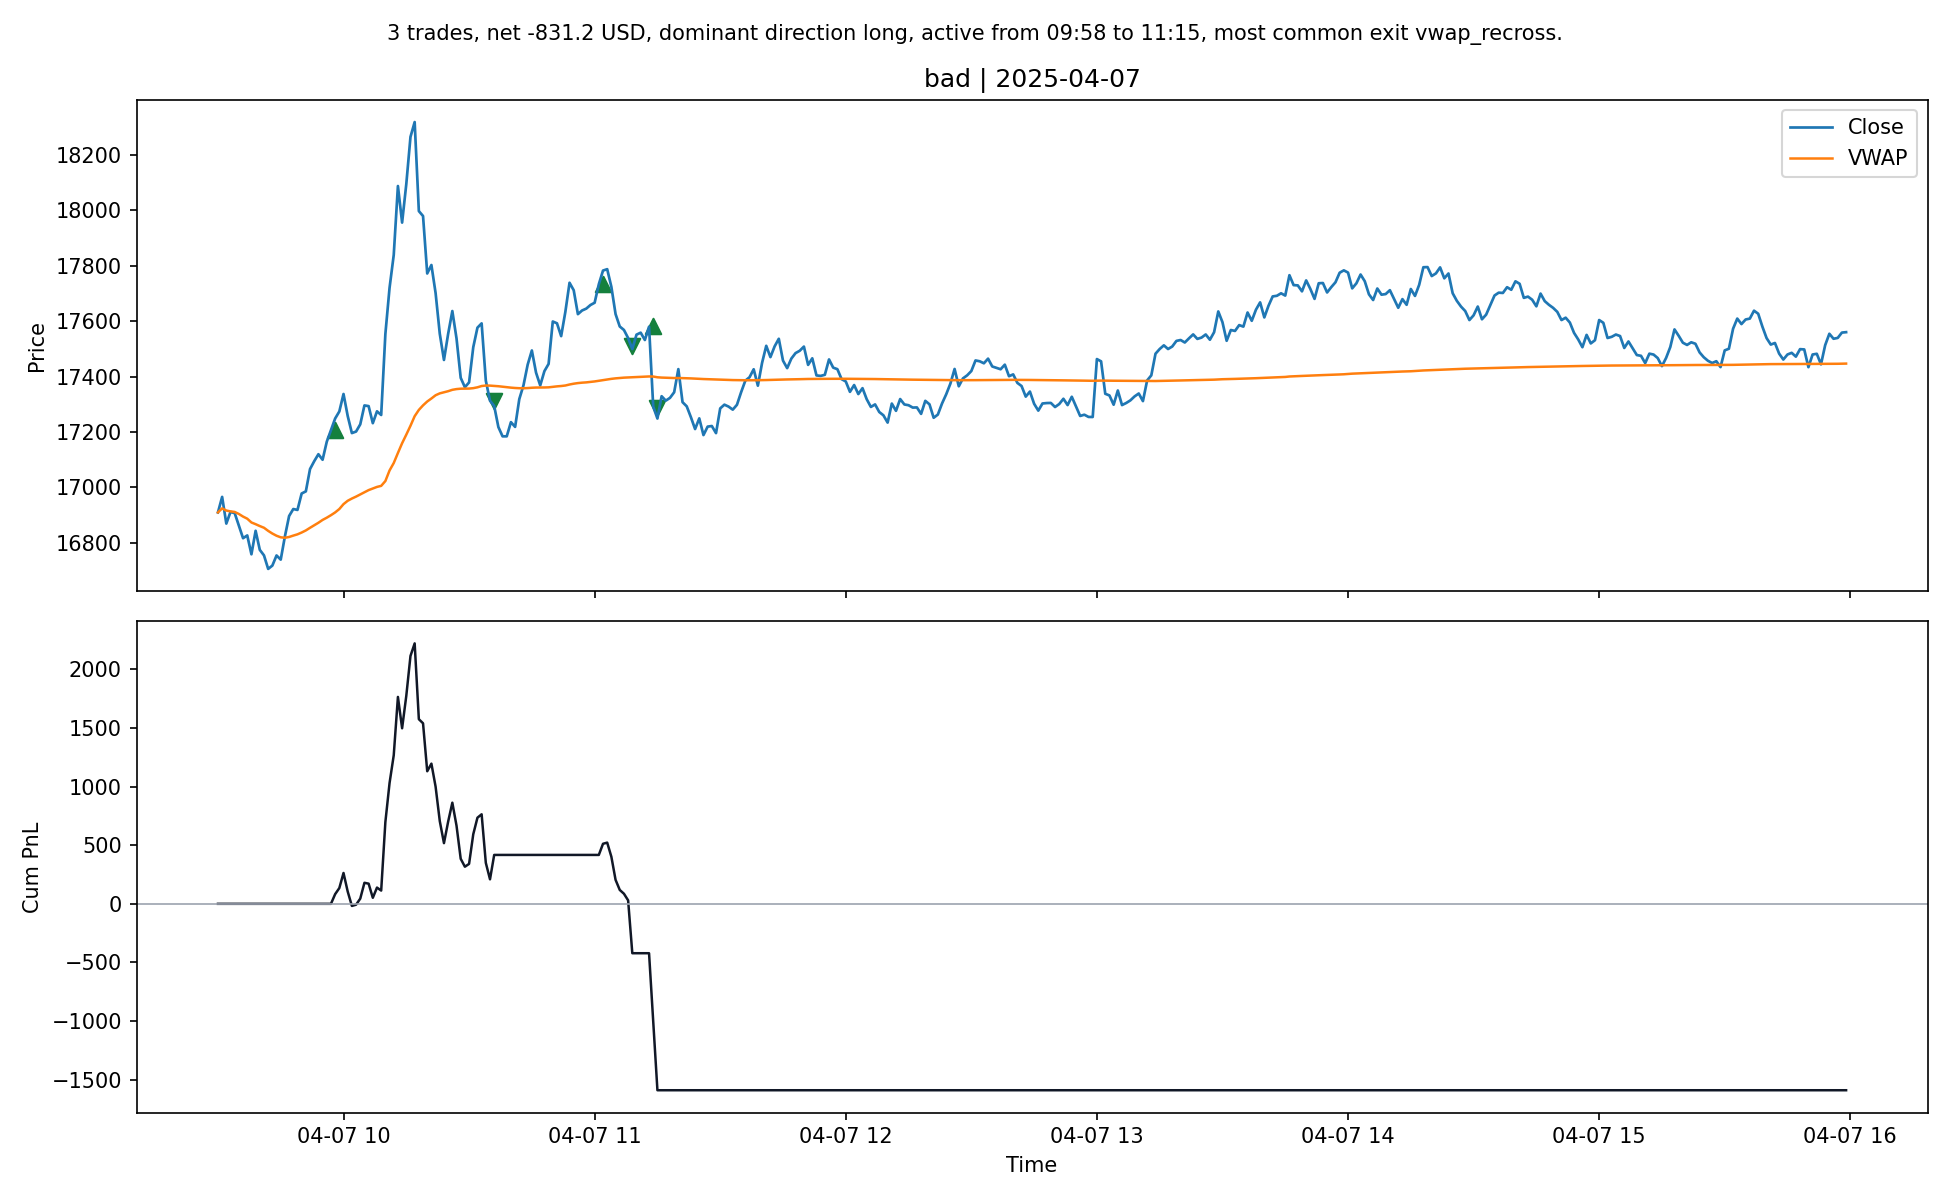

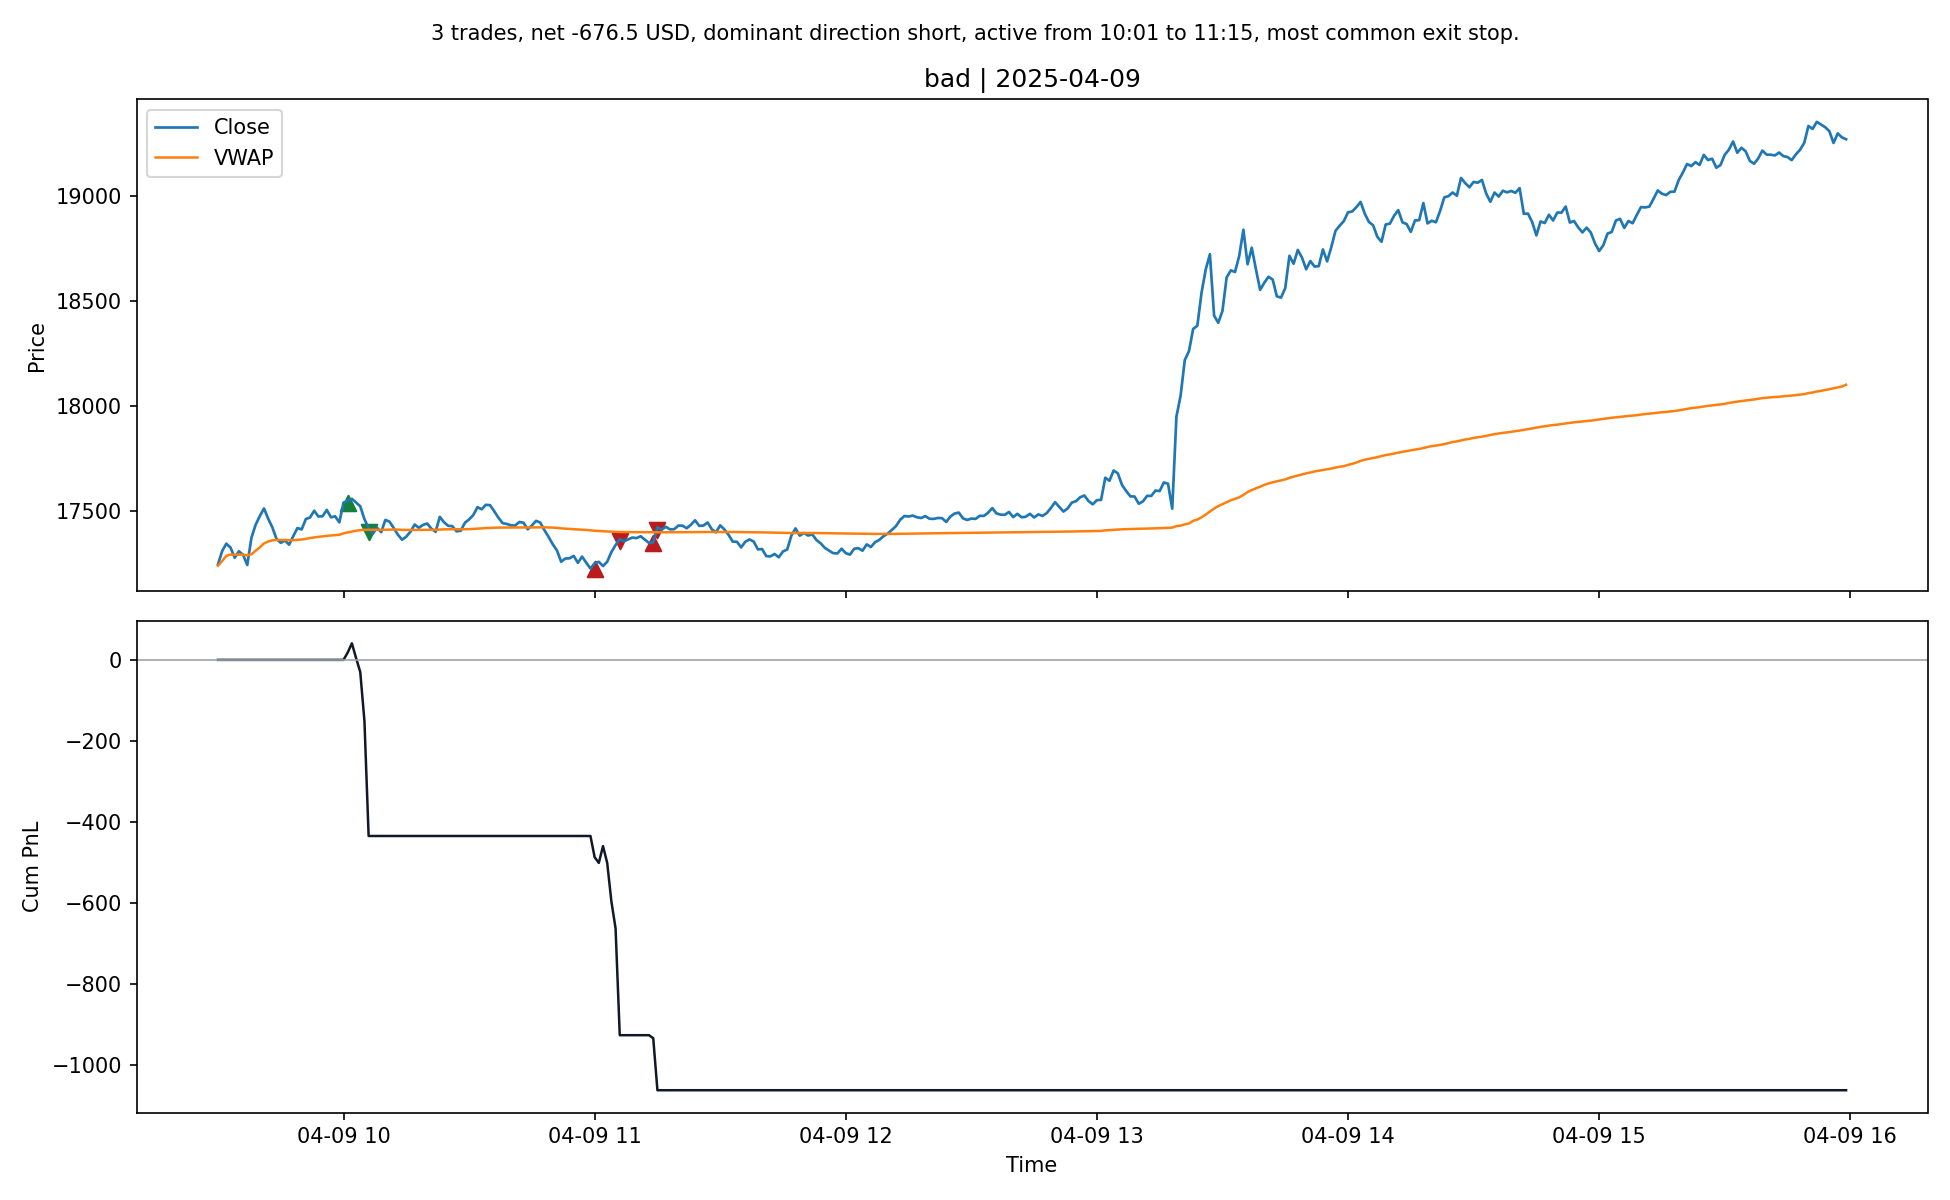

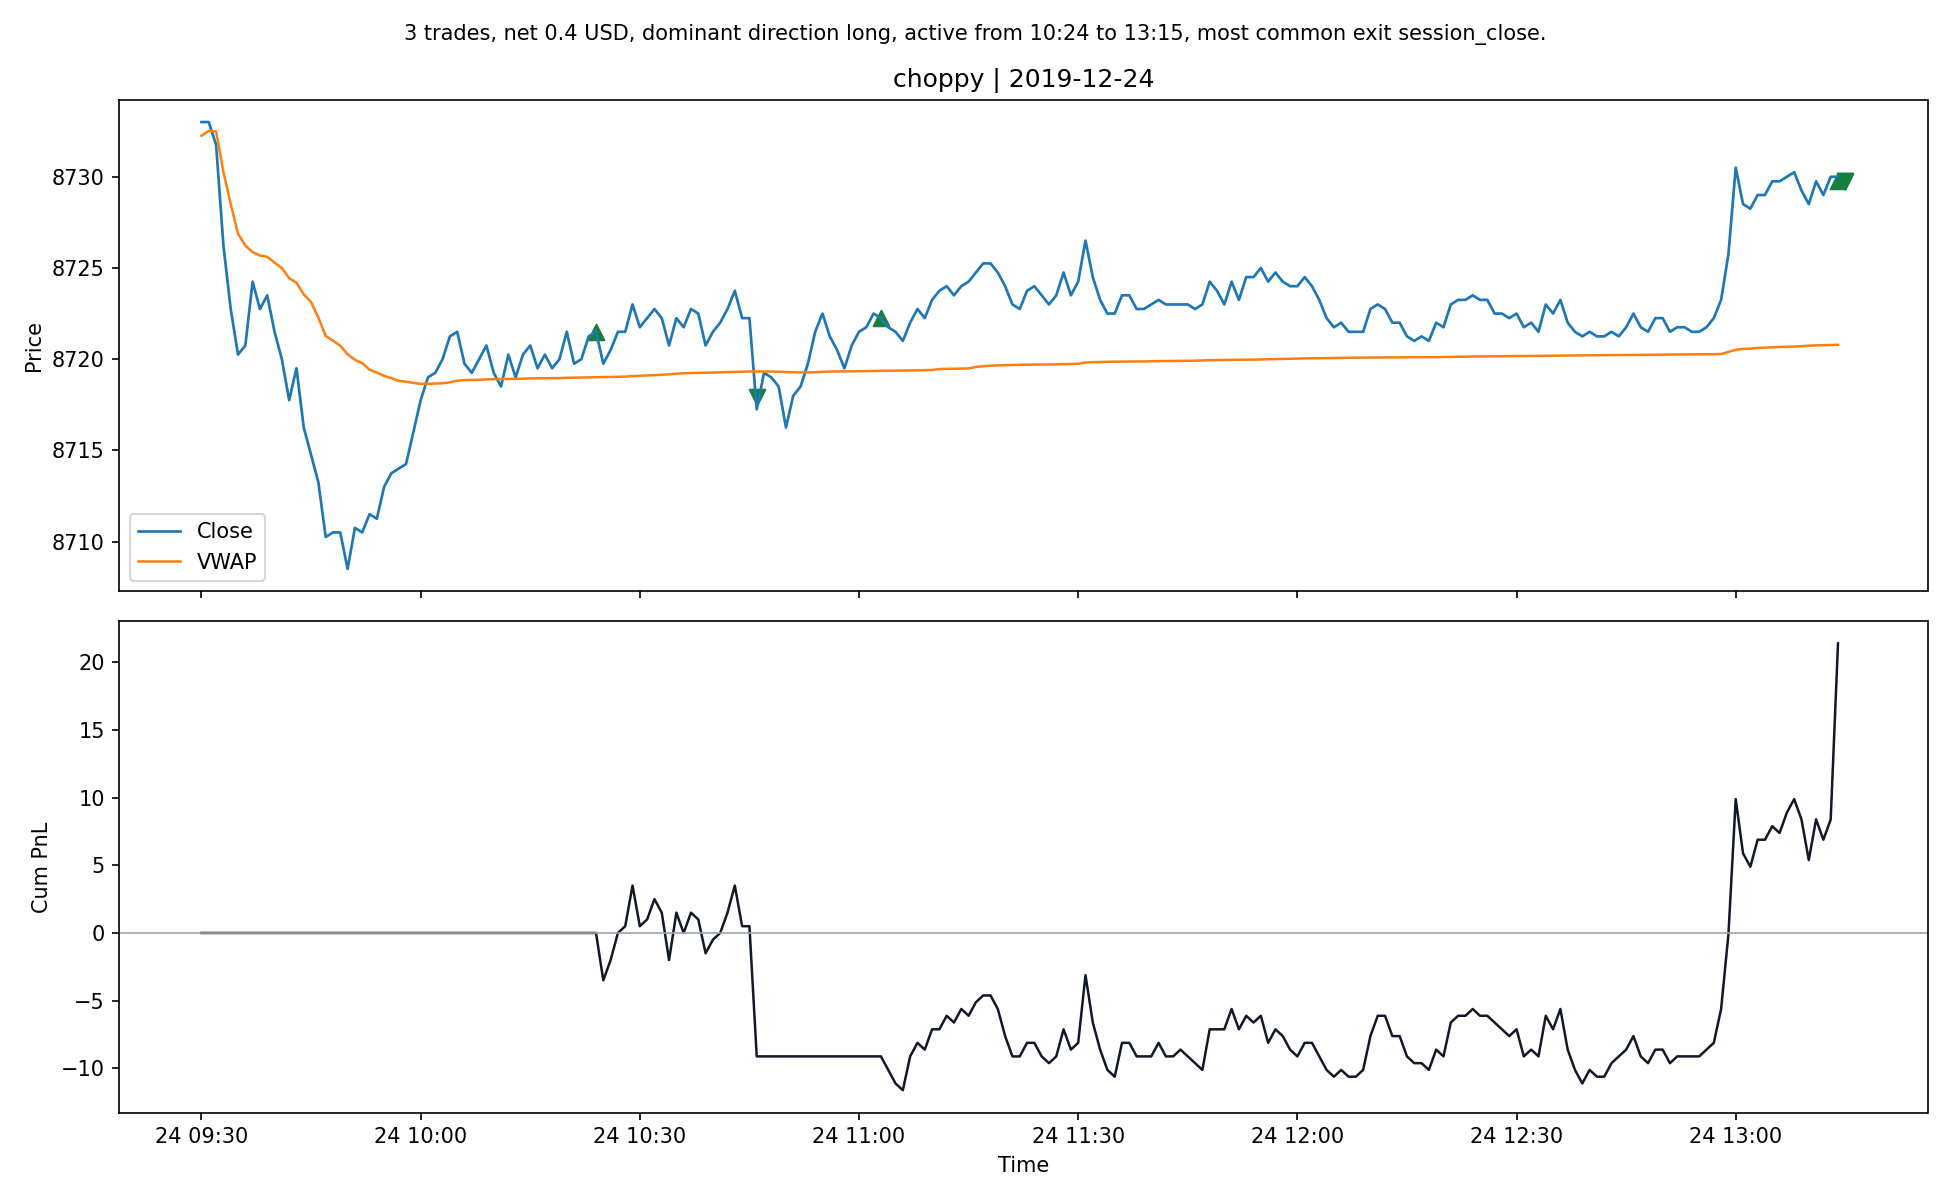

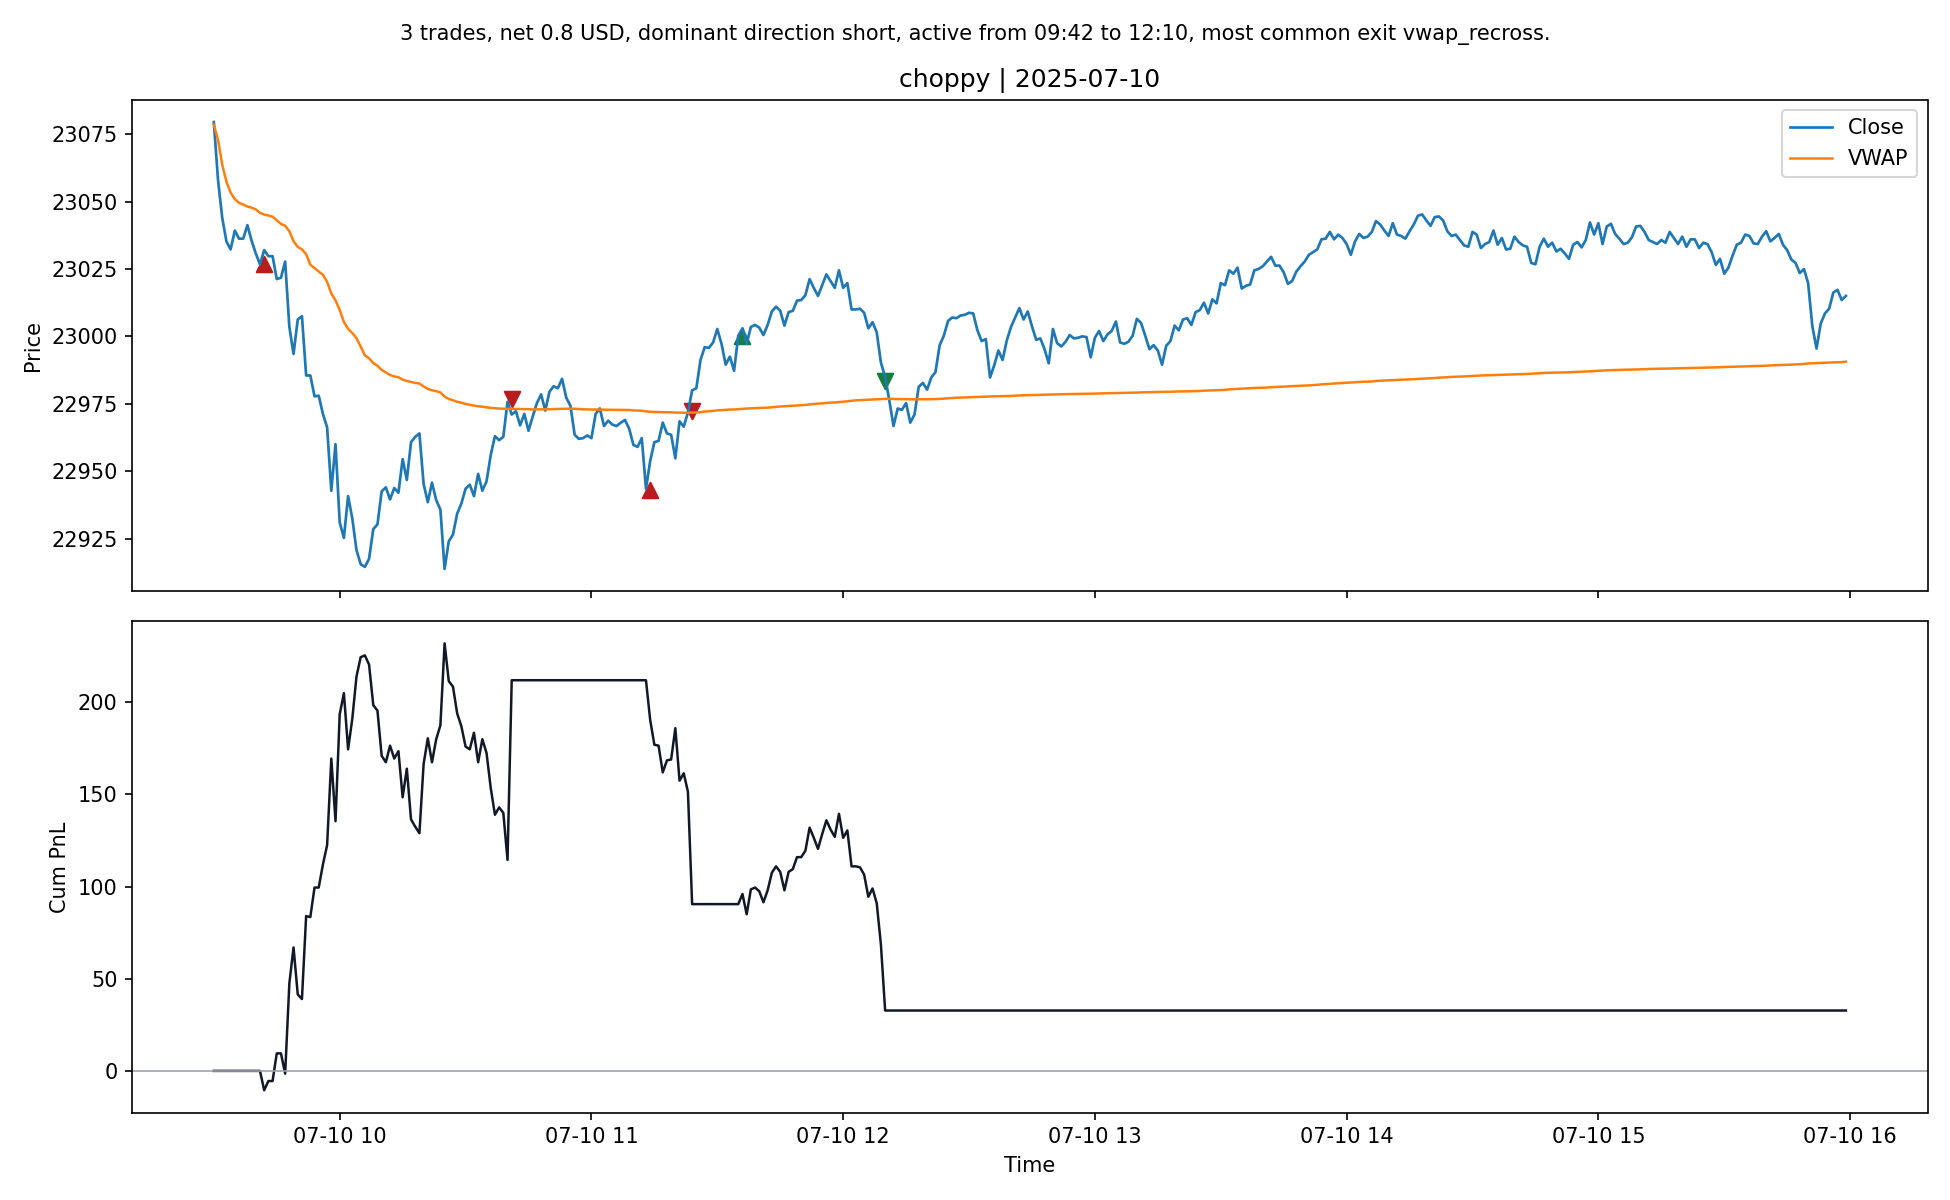

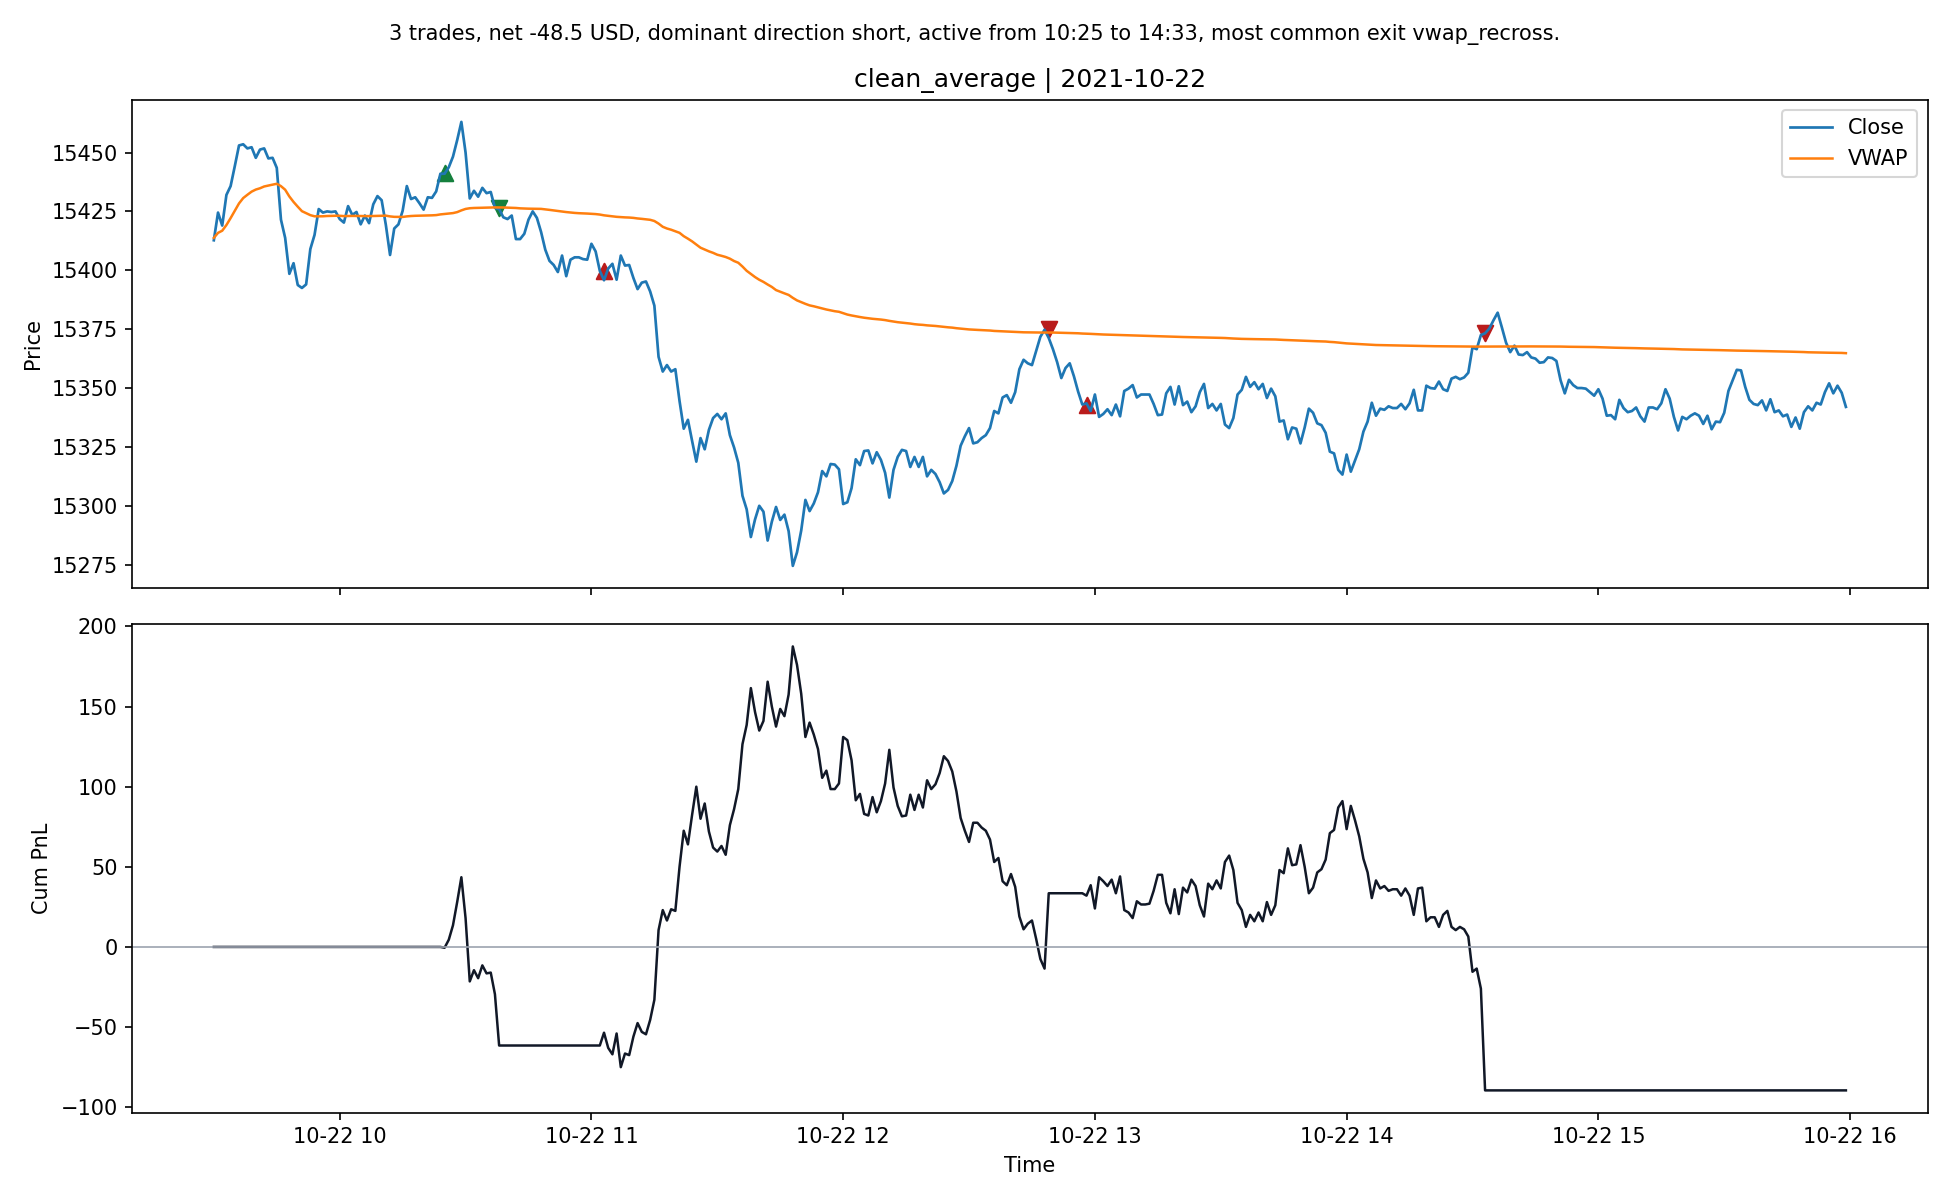

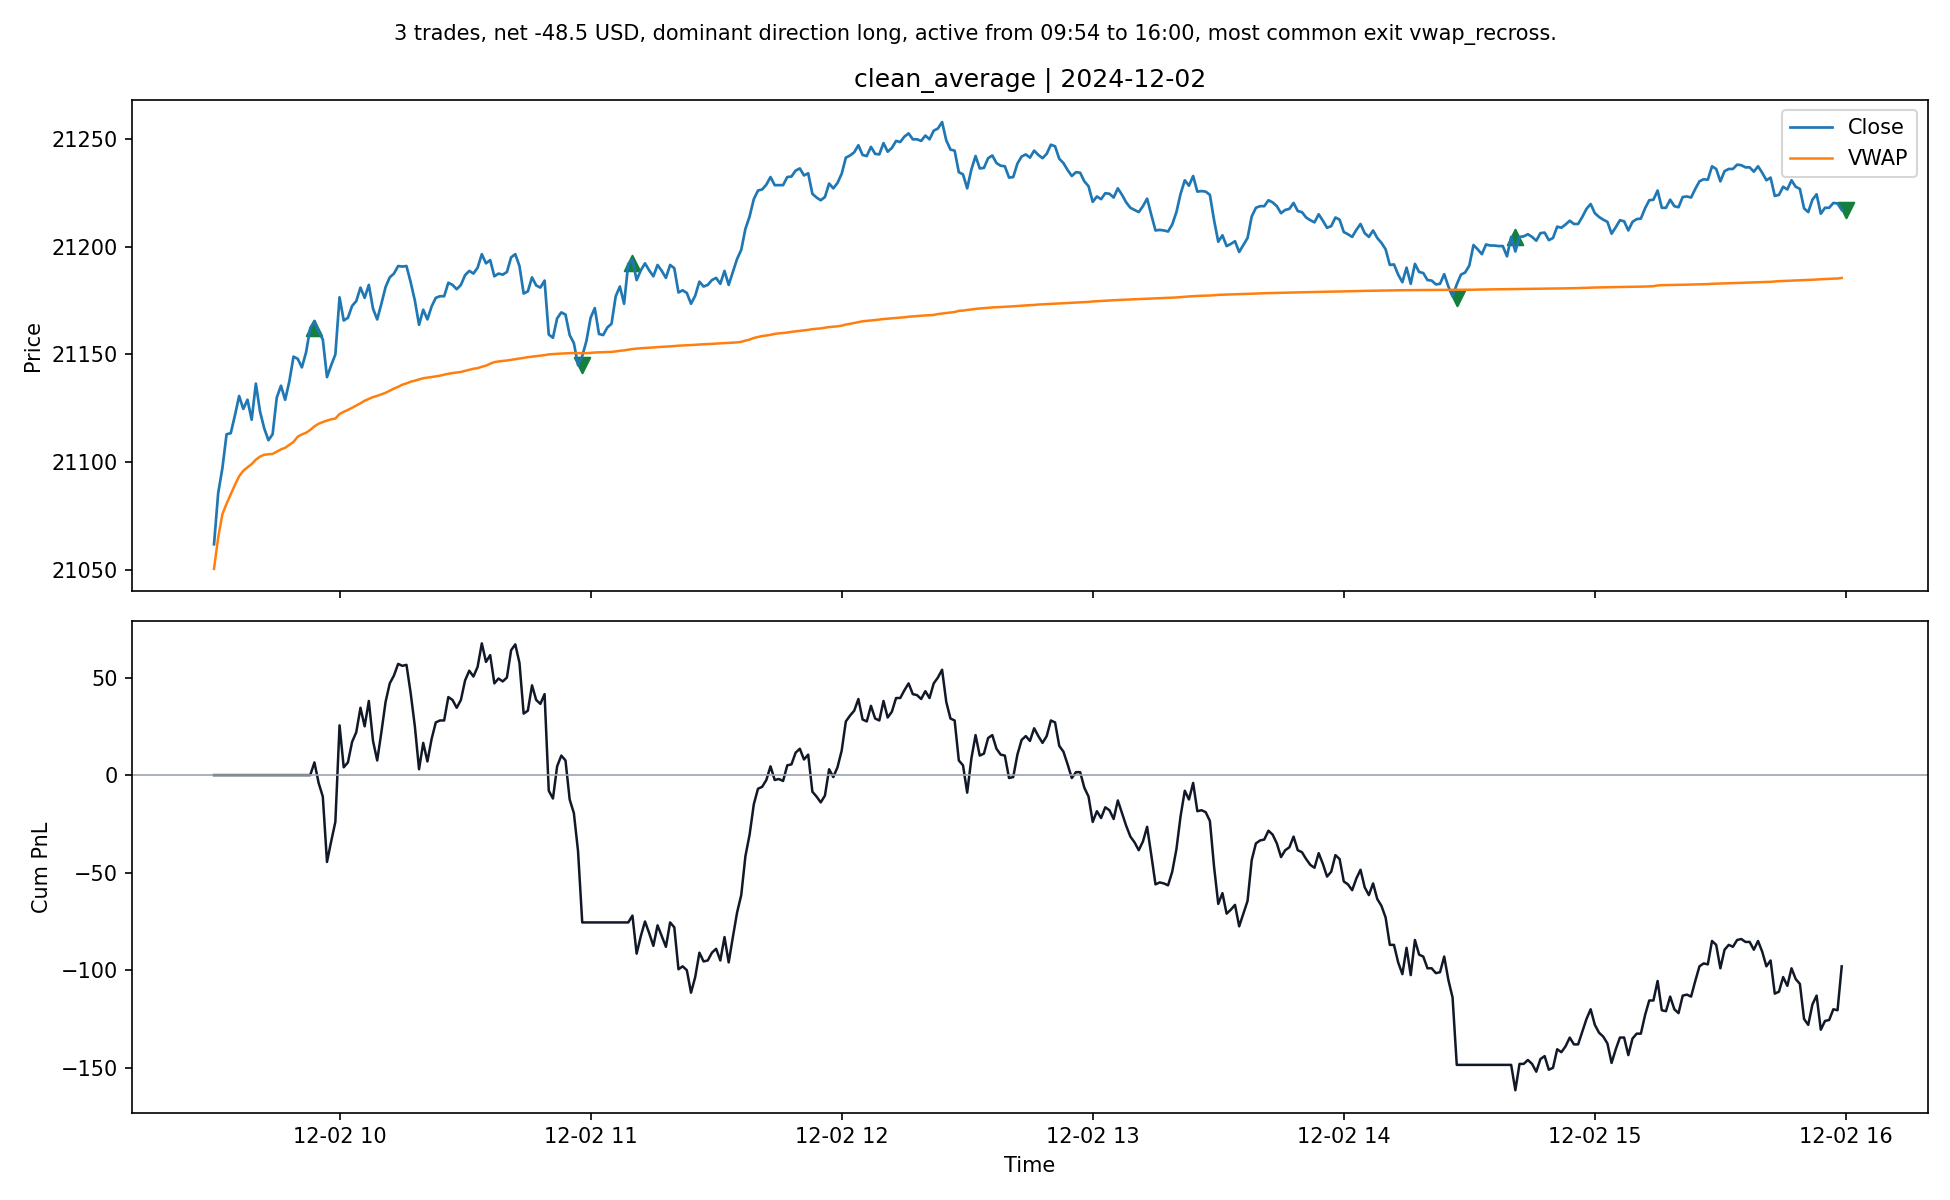

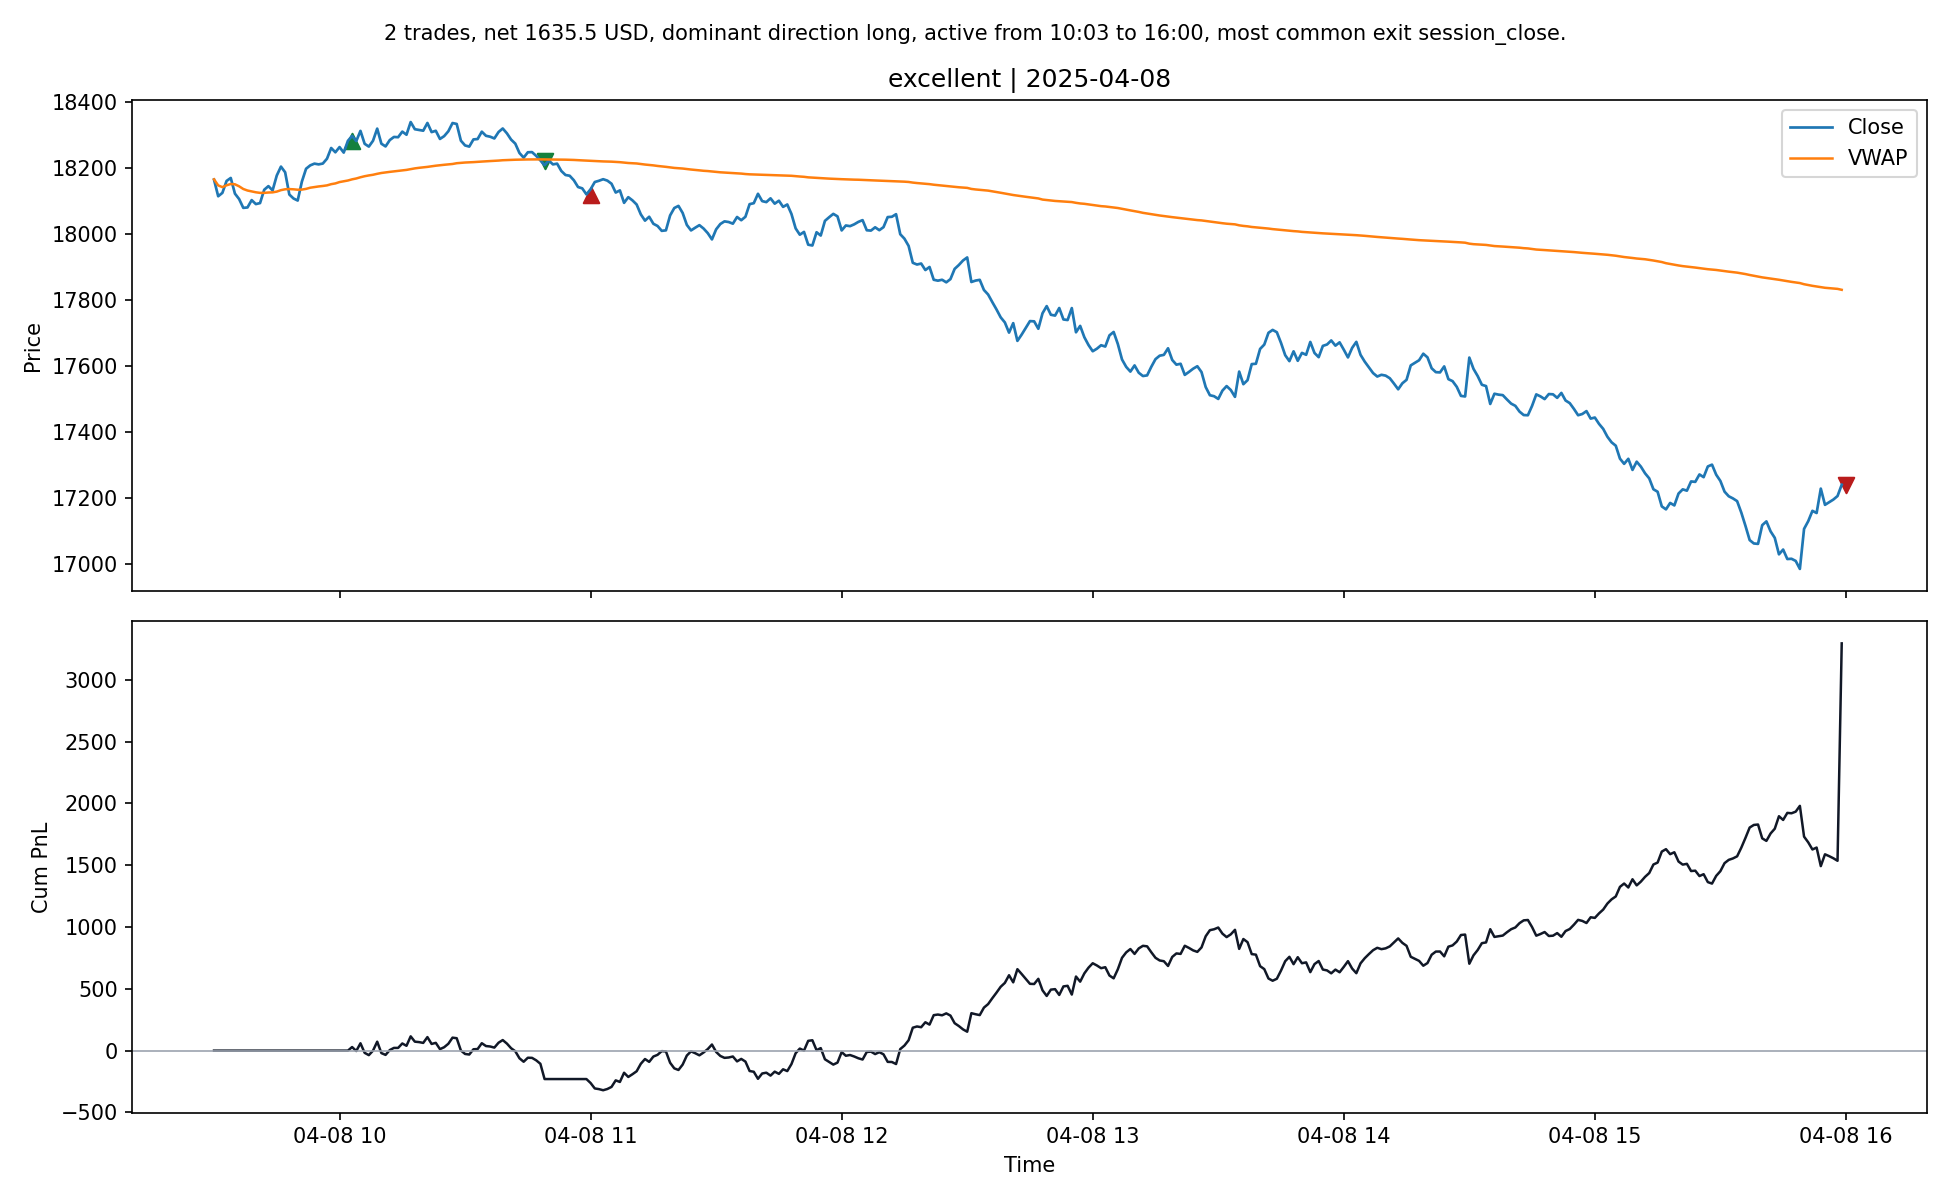

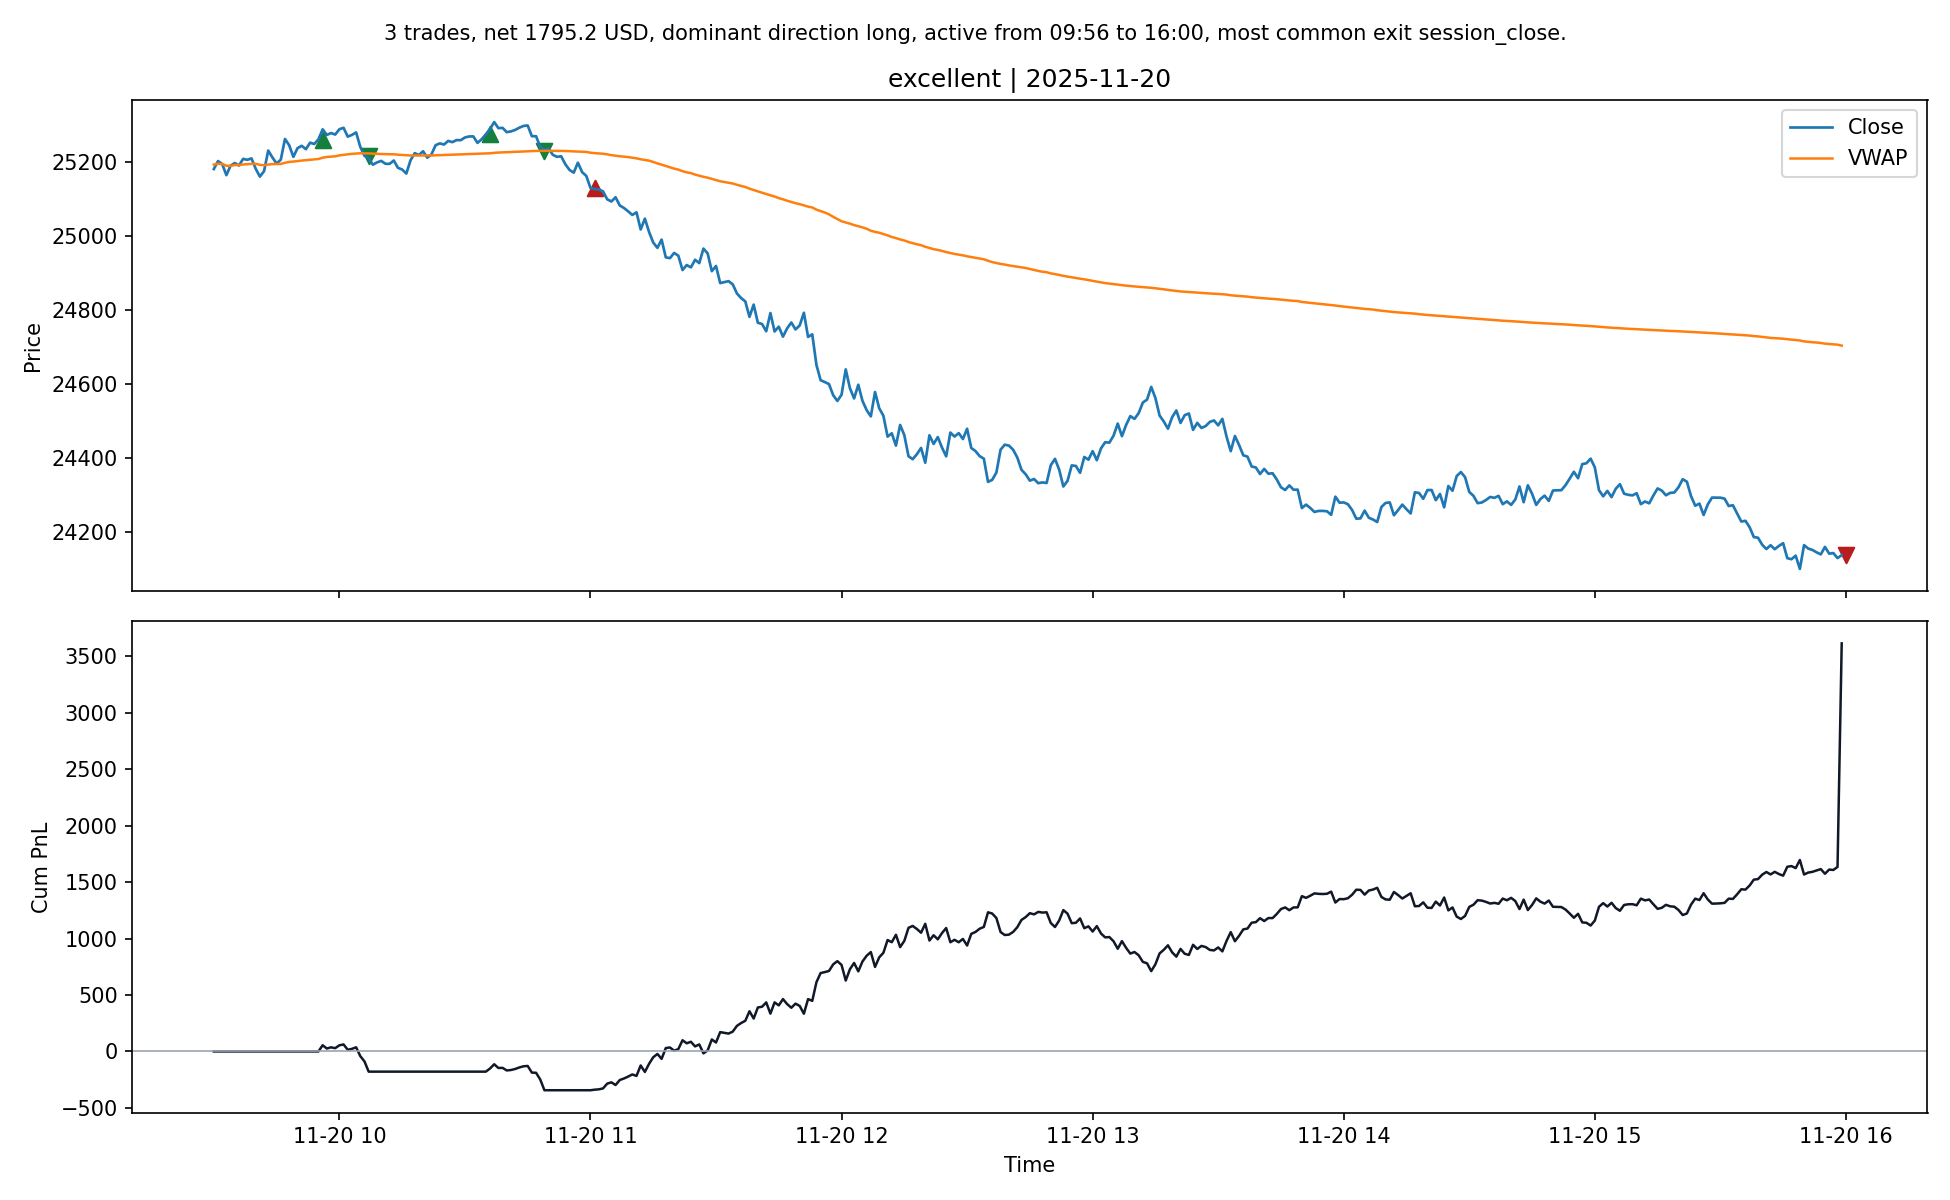

In [12]:
path = OUTPUT_DIR / "representative_days" / "representative_days.csv"
if path.exists():
    display(pd.read_csv(path))
for png in sorted((OUTPUT_DIR / "representative_days" / "charts").glob("*.png")):
    display(Image(filename=str(png)))


## 11) Final Verdict

The final report above is the decision-ready source of truth.
